In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: # allow memory growth
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU config error:", e)


2025-12-14 20:50:46.547214: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pennylane as qml
import gc 

In [4]:
# ---------------------------------------------------------------------
# REGISTERED CUSTOM OPTIMIZER
# ---------------------------------------------------------------------
from keras.saving import register_keras_serializable

@register_keras_serializable(package="custom", name="AdamSGDHybrid")
class AdamSGDHybrid(tf.keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999,
                 epsilon=1e-7, momentum=0.9, mix_factor=0.5, name="AdamSGDHybrid", **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.momentum = momentum
        self.mix_factor = mix_factor

    def build(self, var_list):
        self.m, self.v, self.sgd_mom = [], [], []
        for var in var_list:
            self.m.append(self.add_variable_from_reference(var, "m"))
            self.v.append(self.add_variable_from_reference(var, "v"))
            self.sgd_mom.append(self.add_variable_from_reference(var, "sgd_mom"))
        super().build(var_list)

    def update_step(self, grad, var, lr):
        if grad is None: return
        idx = self._get_variable_index(var)
        m, v, sgd_mom = self.m[idx], self.v[idx], self.sgd_mom[idx]

        # Adam update
        m.assign(self.beta1 * m + (1. - self.beta1) * grad)
        v.assign(self.beta2 * v + (1. - self.beta2) * tf.square(grad))
        adam_update = m / (tf.sqrt(v) + self.epsilon)

        # SGD momentum update
        sgd_mom.assign(self.momentum * sgd_mom + grad)
        sgd_update = sgd_mom

        # Hybrid update
        update = self.mix_factor * adam_update + (1. - self.mix_factor) * sgd_update
        var.assign_sub(lr * update)

    def get_config(self):
        config = super().get_config()
        config.update({
            "beta1": self.beta1,
            "beta2": self.beta2,
            "epsilon": self.epsilon,
            "momentum": self.momentum,
            "mix_factor": self.mix_factor,
        })
        return config

# ---------------------------------------------------------------------
# CUSTOM LAYER FOR QUANTUM MODELS
# ---------------------------------------------------------------------
class QuantumInspiredLayer(layers.Layer):
    def __init__(self, n_qubits=4, n_layers=2, **kwargs):
        super().__init__(**kwargs)
        self.n_qubits = n_qubits
        self.n_layers = n_layers

    def build(self, input_shape):
        self.rotation_weights = self.add_weight(
            name="rotation_weights",
            shape=(self.n_layers, self.n_qubits, 2),
            initializer=keras.initializers.RandomUniform(0, 2*np.pi),
            trainable=True
        )
        self.interaction_weights = self.add_weight(
            name="interaction_weights",
            shape=(self.n_layers, self.n_qubits, self.n_qubits),
            initializer=keras.initializers.GlorotUniform(),
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        x = inputs
        for layer in range(self.n_layers):
            ry_transform = tf.cos(self.rotation_weights[layer, :, 0]) * x + \
                           tf.sin(self.rotation_weights[layer, :, 0]) * tf.roll(x, shift=1, axis=-1)
            rz_transform = tf.cos(self.rotation_weights[layer, :, 1]) * ry_transform - \
                           tf.sin(self.rotation_weights[layer, :, 1]) * tf.roll(ry_transform, shift=-1, axis=-1)
            interaction = tf.matmul(tf.expand_dims(rz_transform, -1), tf.expand_dims(rz_transform, -2))
            interaction_effect = tf.reduce_sum(interaction * self.interaction_weights[layer], axis=-1)
            x = tf.tanh(rz_transform + 0.1 * interaction_effect)
        return x

In [5]:
# ---------------------------------------------------------------------
# CLASS NAMES AND TEST DIRECTORY
# ---------------------------------------------------------------------
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
TEST_DIR = "/mnt/c/Users/hassa/OneDrive/Desktop/QML/Brain_Tumor_data/Testing"

# ---------------------------------------------------------------------
# LOAD TEST DATA AS NUMPY ARRAY
# ---------------------------------------------------------------------
IMG_SIZE = (64, 64)   # adjust if needed

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    shuffle=False,
    batch_size=32
)

X_test = np.concatenate([x for x, _ in test_ds], axis=0)
y_test = np.concatenate([y for _, y in test_ds], axis=0)

X_test = X_test / 255.0

Found 1311 files belonging to 4 classes.


I0000 00:00:1765745494.152671    8681 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
2025-12-14 20:51:34.815751: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-12-14 20:51:35.285090: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
# ---------------------------------------------------------------------
# MODEL PATHS (fixed HybridAdamSDG path)
# ---------------------------------------------------------------------
model_paths = {
    "ML-CNN": {
        "ADAM":    r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/ADAM/models/classical_cnn_complete.keras",
        "ADAGRAD": r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/ADAGRAD/cnn/adagrad_models/classical_cnn_Adagrad_complete.keras",
        "SGD":     r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/SDG/sdg-models/classical_cnn_SGD_complete.keras",
        "HybridAdamSDG": r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/HybridOptimizer/MLCNN/classical_cnn_AdamSGD_complete.keras"
    },
    "Quantum-CNN": {
        "ADAM":    r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/ADAM/models/quantum_cnn_brain_tumor_model.keras",
        "ADAGRAD": r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/ADAGRAD/qcnn/models/quantum_cnn_brain_tumor_model.keras",
        "SGD":     r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/SDG/sdg-models/quantum_cnn_brain_tumor_model.keras",
        "HybridAdamSDG": r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/HybridOptimizer/QCNN/qcnn-models/centralized_quantum_brain_tumor_model.keras"
    },
    "Federated-CNN": {
        "ADAM":    r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/ADAM/models/federated_model_round_5.keras",
        "ADAGRAD": r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/ADAGRAD/flcnn/sdg-models/federated_model_round_5.keras",
        "SGD":     r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/SDG/sdg-models/federated_model_round_5.keras",
        "HybridAdamSDG": r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/HybridOptimizer/FLCNN/sdg-models/federated_model_round_5.keras"
    },
    "Federated-Quantum-CNN": {
        "ADAM":    r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/ADAM/models/federated_quantum_model_round_5.keras",
        "ADAGRAD": r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/ADAGRAD/flqcnn/flq-models/federated_quantum_model_round_5.keras",
        "SGD":     r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/SDG/sdg-graphs/flqcnn/flq-models/federated_quantum_model_round_5.keras",
        "HybridAdamSDG": r"/mnt/c/Users/hassa/OneDrive/Desktop/QML/HybridOptimizer/FLQCNN/flq-models/federated_quantum_model_round_5.keras"
    },
}

model_types = ["ML-CNN", "Quantum-CNN", "Federated-CNN", "Federated-Quantum-CNN"]
optimizers = ["ADAM", "ADAGRAD", "SGD", "HybridAdamSDG"]


# ---------------------------------------------------------------------
# CONFUSION MATRIX PLOT FUNCTION (improved visibility)
# ---------------------------------------------------------------------
def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="viridis",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        annot_kws={"size": 14, "weight": "bold"}  # <-- bigger, bolder numbers
    )
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)


# ---------------------------------------------------------------------
# GENERATE GRID
# ---------------------------------------------------------------------
fig, axes = plt.subplots(nrows=len(model_types), ncols=len(optimizers),
                         figsize=(28, 28), dpi=350)

custom_objects = {"QuantumInspiredLayer": QuantumInspiredLayer,
                  "AdamSGDHybrid": AdamSGDHybrid}

for i, model_type in enumerate(model_types):
    for j, optimizer in enumerate(optimizers):
        model_path = model_paths[model_type][optimizer]
        ax = axes[i, j]
        
        print(f"\nProcessing: {model_type} - {optimizer}")
        
        try:
            # 1. compile=False avoids loading the optimizer (saves RAM, fixes warnings)
            model = load_model(model_path, custom_objects=custom_objects, compile=False)
            
            # 2. Predict
            y_pred_probs = model.predict(X_test, verbose=0)
            y_pred = np.argmax(y_pred_probs, axis=1)
            
            # 3. Plot
            plot_cm(ax, y_test, y_pred, f"{model_type} | {optimizer}")
            
            # 4. AGGRESSIVE MEMORY CLEANUP
            del model         # Delete the reference
            tf.keras.backend.clear_session() # Clear TF graph
            gc.collect()      # Force Python garbage collection
            
        except Exception as e:
            print(f"FAILED to load {model_type}-{optimizer}: {e}")
            ax.text(0.5, 0.5, "Model Load Failed", 
                    ha='center', va='center', fontsize=14, color='red')

plt.tight_layout()
plt.savefig("Final_confusion_matrix_all_models.png", dpi=800, bbox_inches="tight") # Reduced dpi slightly for safety
plt.show()



Processing: ML-CNN - ADAM


2025-12-14 20:51:38.847622: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fa12000f830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-14 20:51:38.847659: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-12-14 20:51:38.991348: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-14 20:51:39.347772: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2025-12-14 20:51:40.248215: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_272', 60 bytes spill stores, 60 bytes spill loads

I0000 00:00:1765745504.738318    8967 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at


Processing: ML-CNN - ADAGRAD


2025-12-14 20:51:53.778429: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_218', 8 bytes spill stores, 8 bytes spill loads




Processing: ML-CNN - SGD

Processing: ML-CNN - HybridAdamSDG

Processing: Quantum-CNN - ADAM

Processing: Quantum-CNN - ADAGRAD

Processing: Quantum-CNN - SGD

Processing: Quantum-CNN - HybridAdamSDG

Processing: Federated-CNN - ADAM

Processing: Federated-CNN - ADAGRAD

Processing: Federated-CNN - SGD

Processing: Federated-CNN - HybridAdamSDG

Processing: Federated-Quantum-CNN - ADAM

Processing: Federated-Quantum-CNN - ADAGRAD

Processing: Federated-Quantum-CNN - SGD

Processing: Federated-Quantum-CNN - HybridAdamSDG


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
OUT_DIR = Path("/mnt/c/Users/hassa/OneDrive/Desktop/QML/results")
CSV_PATH = Path("/mnt/c/Users/hassa/OneDrive/Desktop/QML/FINAL_RESEARCH_DATA.csv")

OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv(CSV_PATH)

# Convert numeric columns
num_cols = ["Epoch", "TimeSec", "TrainAcc", "ValAcc", "TrainLoss", "ValLoss", "LR"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df.head()


,Optimizer,ModelType,Round_Fold,Client,Epoch,TimeSec,TrainAcc,ValAcc,TrainLoss,ValLoss,LR
0,Adagrad,FEDERATED CNN,1,1.0,1,19.809530,0.500437,0.263804,1.343691,2.297373,0.001
1,Adagrad,FEDERATED CNN,1,1.0,2,6.223229,0.606299,0.263804,1.036047,2.297373,0.001
2,Adagrad,FEDERATED CNN,1,1.0,3,6.180118,0.644794,0.263804,0.938923,2.297373,0.001
3,Adagrad,FEDERATED CNN,1,1.0,4,6.127594,0.691164,0.263804,0.844261,2.297373,0.001
4,Adagrad,FEDERATED CNN,1,1.0,5,6.174047,0.688539,0.263804,0.823604,2.297373,0.001


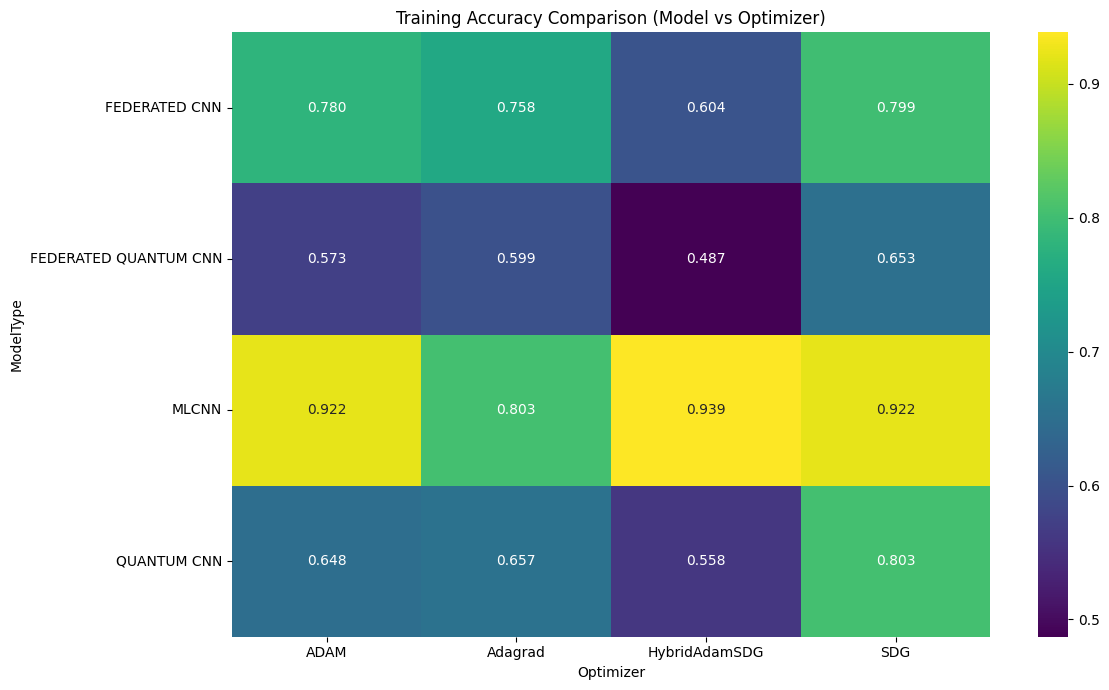

In [2]:
plt.figure(figsize=(12,7))
pivot = df.pivot_table(
    values="TrainAcc",
    index="ModelType",
    columns="Optimizer",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")
plt.title("Training Accuracy Comparison (Model vs Optimizer)")
plt.tight_layout()
plt.savefig(OUT_DIR/"heatmap_Trainacc.png", dpi=1200)
plt.show()


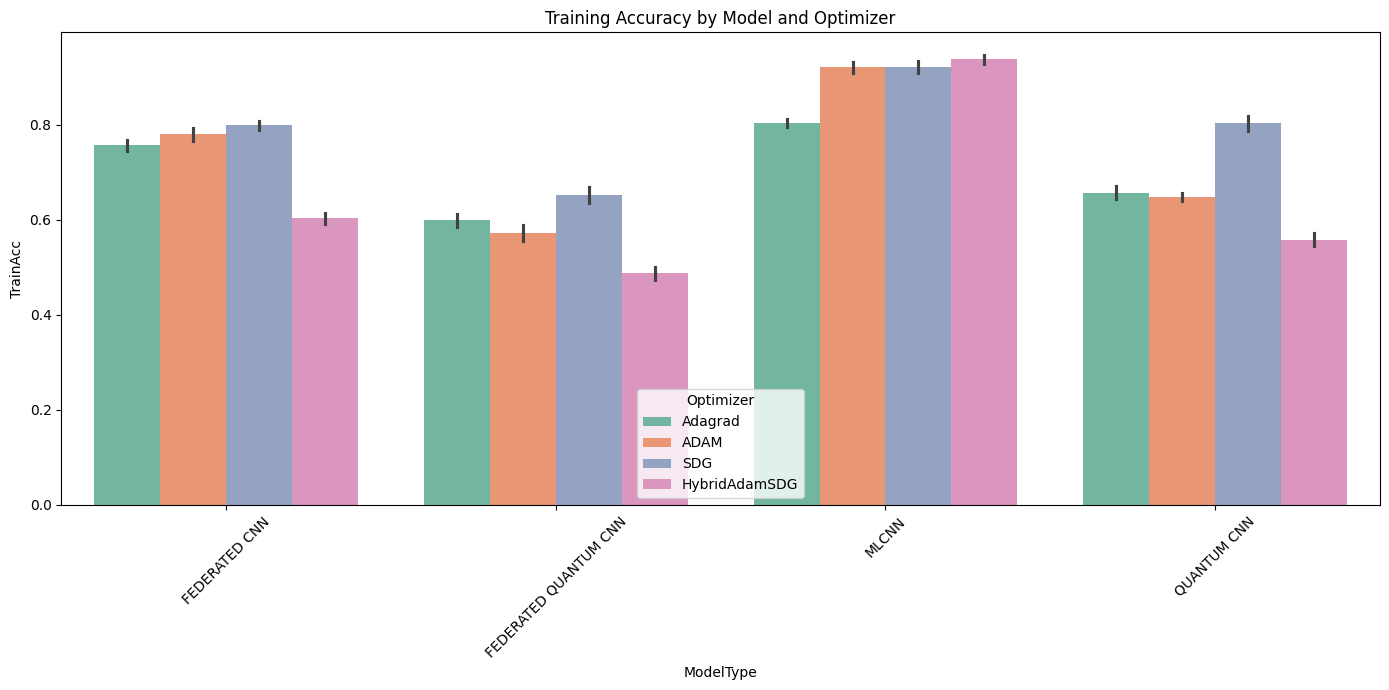

In [3]:
plt.figure(figsize=(14,7))
sns.barplot(
    data=df,
    x="ModelType", y="TrainAcc",
    hue="Optimizer",
    palette="Set2"
)
plt.title("Training Accuracy by Model and Optimizer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR/"bar_accuracy.png", dpi=1200)
plt.show()


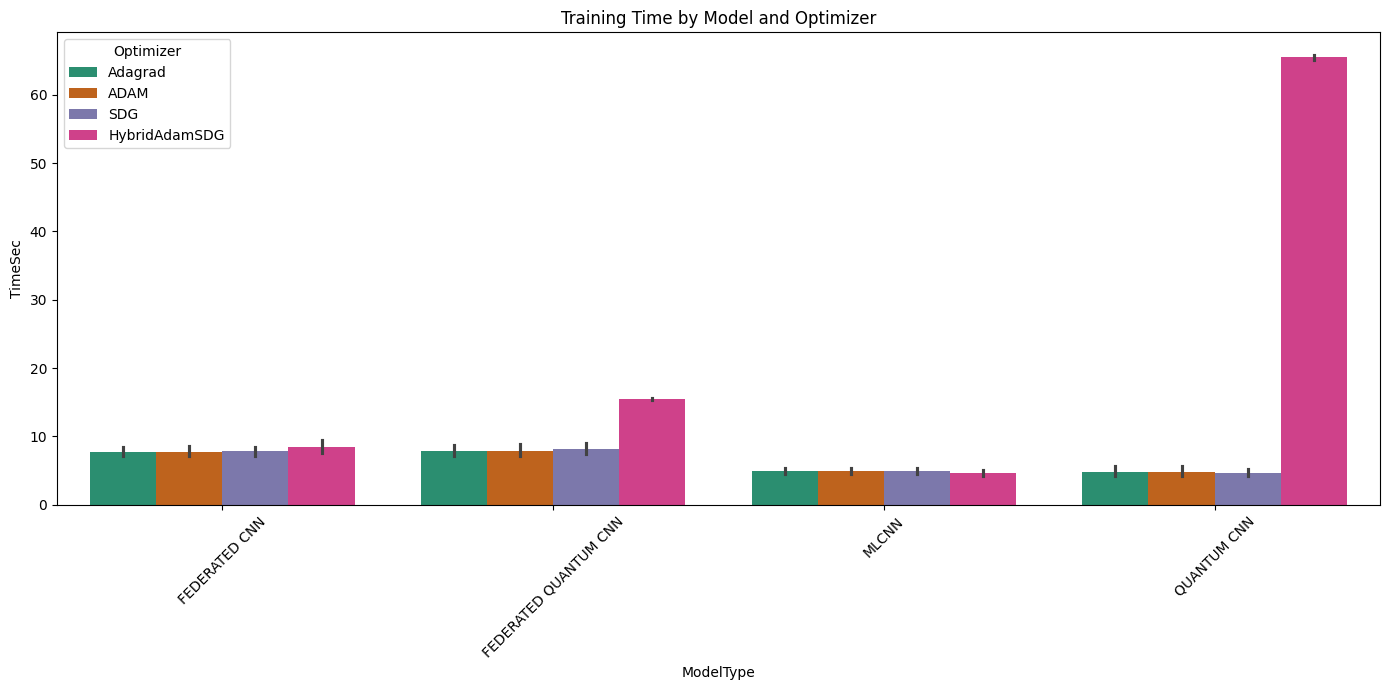

In [4]:
plt.figure(figsize=(14,7))
sns.barplot(
    data=df,
    x="ModelType", y="TimeSec",
    hue="Optimizer",
    palette="Dark2"
)
plt.title("Training Time by Model and Optimizer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR/"training_time.png", dpi=1200)
plt.show()


/tmp/ipykernel_10836/1438172976.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


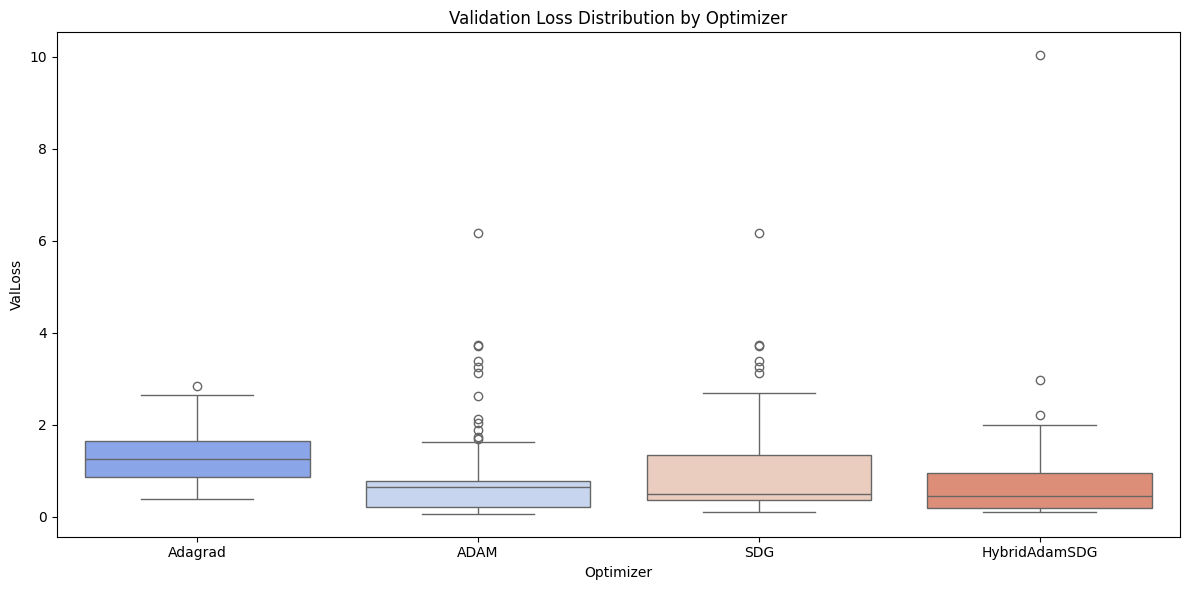

In [5]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x="Optimizer", y="ValLoss",
    palette="coolwarm"
)
plt.title("Validation Loss Distribution by Optimizer")
plt.tight_layout()
plt.savefig(OUT_DIR/"val_loss_boxplot.png", dpi=1200)
plt.show()


/tmp/ipykernel_10836/4025174585.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


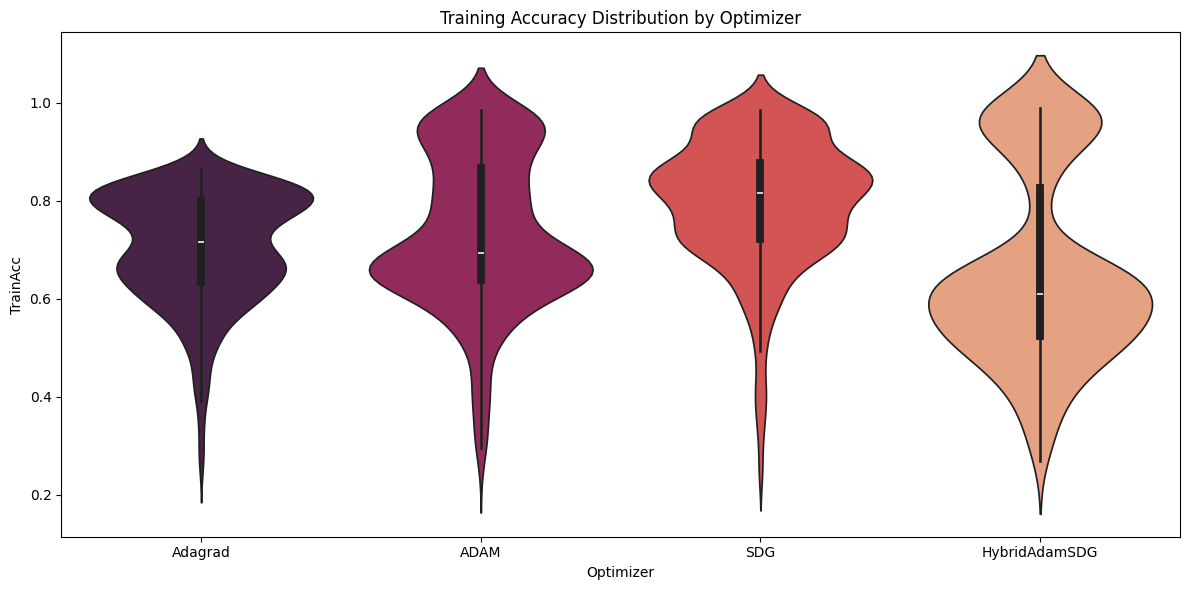

In [6]:
plt.figure(figsize=(12,6))
sns.violinplot(
    data=df,
    x="Optimizer", y="TrainAcc",
    palette="rocket"
)
plt.title("Training Accuracy Distribution by Optimizer")
plt.tight_layout()
plt.savefig(OUT_DIR/"train_acc_violin.png", dpi=1200)
plt.show()


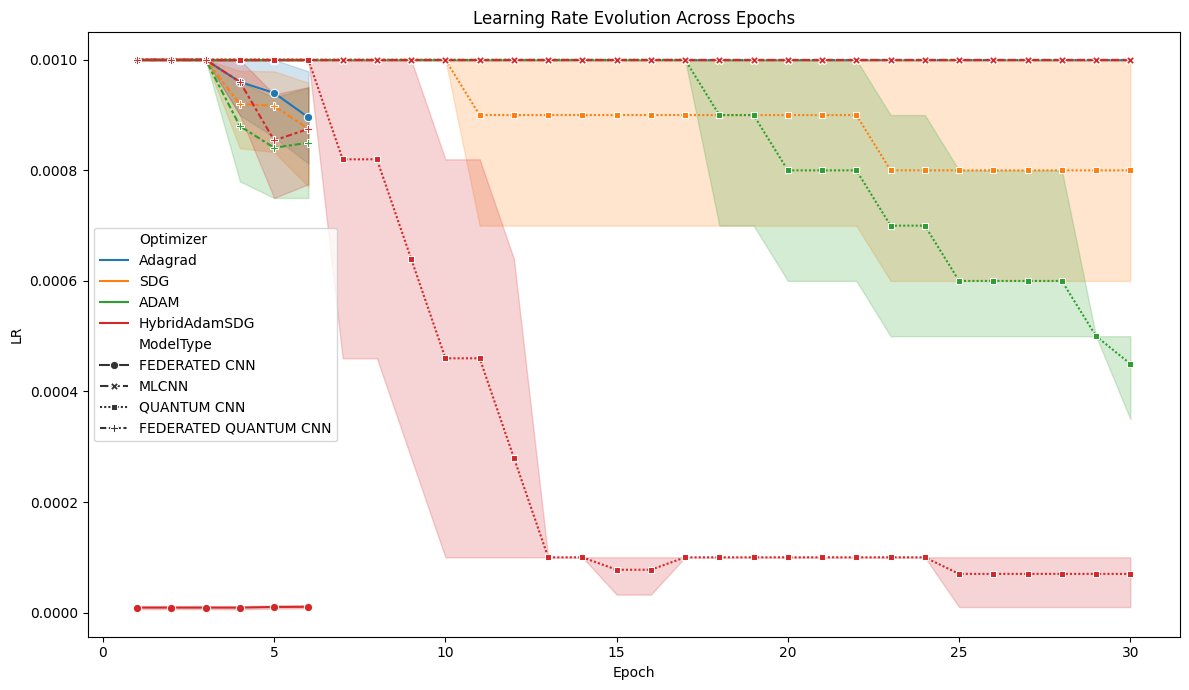

In [7]:
plt.figure(figsize=(12,7))
sns.lineplot(
    data=df.sort_values("Epoch"),
    x="Epoch",
    y="LR",
    hue="Optimizer",
    style="ModelType",
    markers=True
)
plt.title("Learning Rate Evolution Across Epochs")
plt.tight_layout()
plt.savefig(OUT_DIR/"lr_trend.png", dpi=1200)
plt.show()


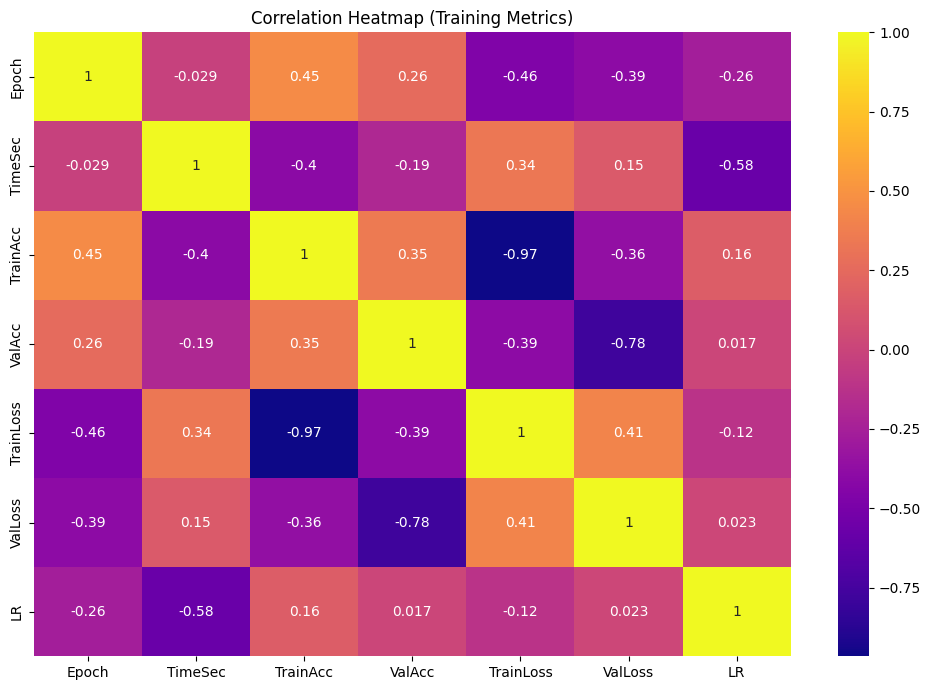

In [8]:
plt.figure(figsize=(10,7))
numeric_df = df[num_cols].dropna()
sns.heatmap(numeric_df.corr(), annot=True, cmap="plasma")
plt.title("Correlation Heatmap (Training Metrics)")
plt.tight_layout()
plt.savefig(OUT_DIR/"correlation_heatmap.png", dpi=1200)
plt.show()


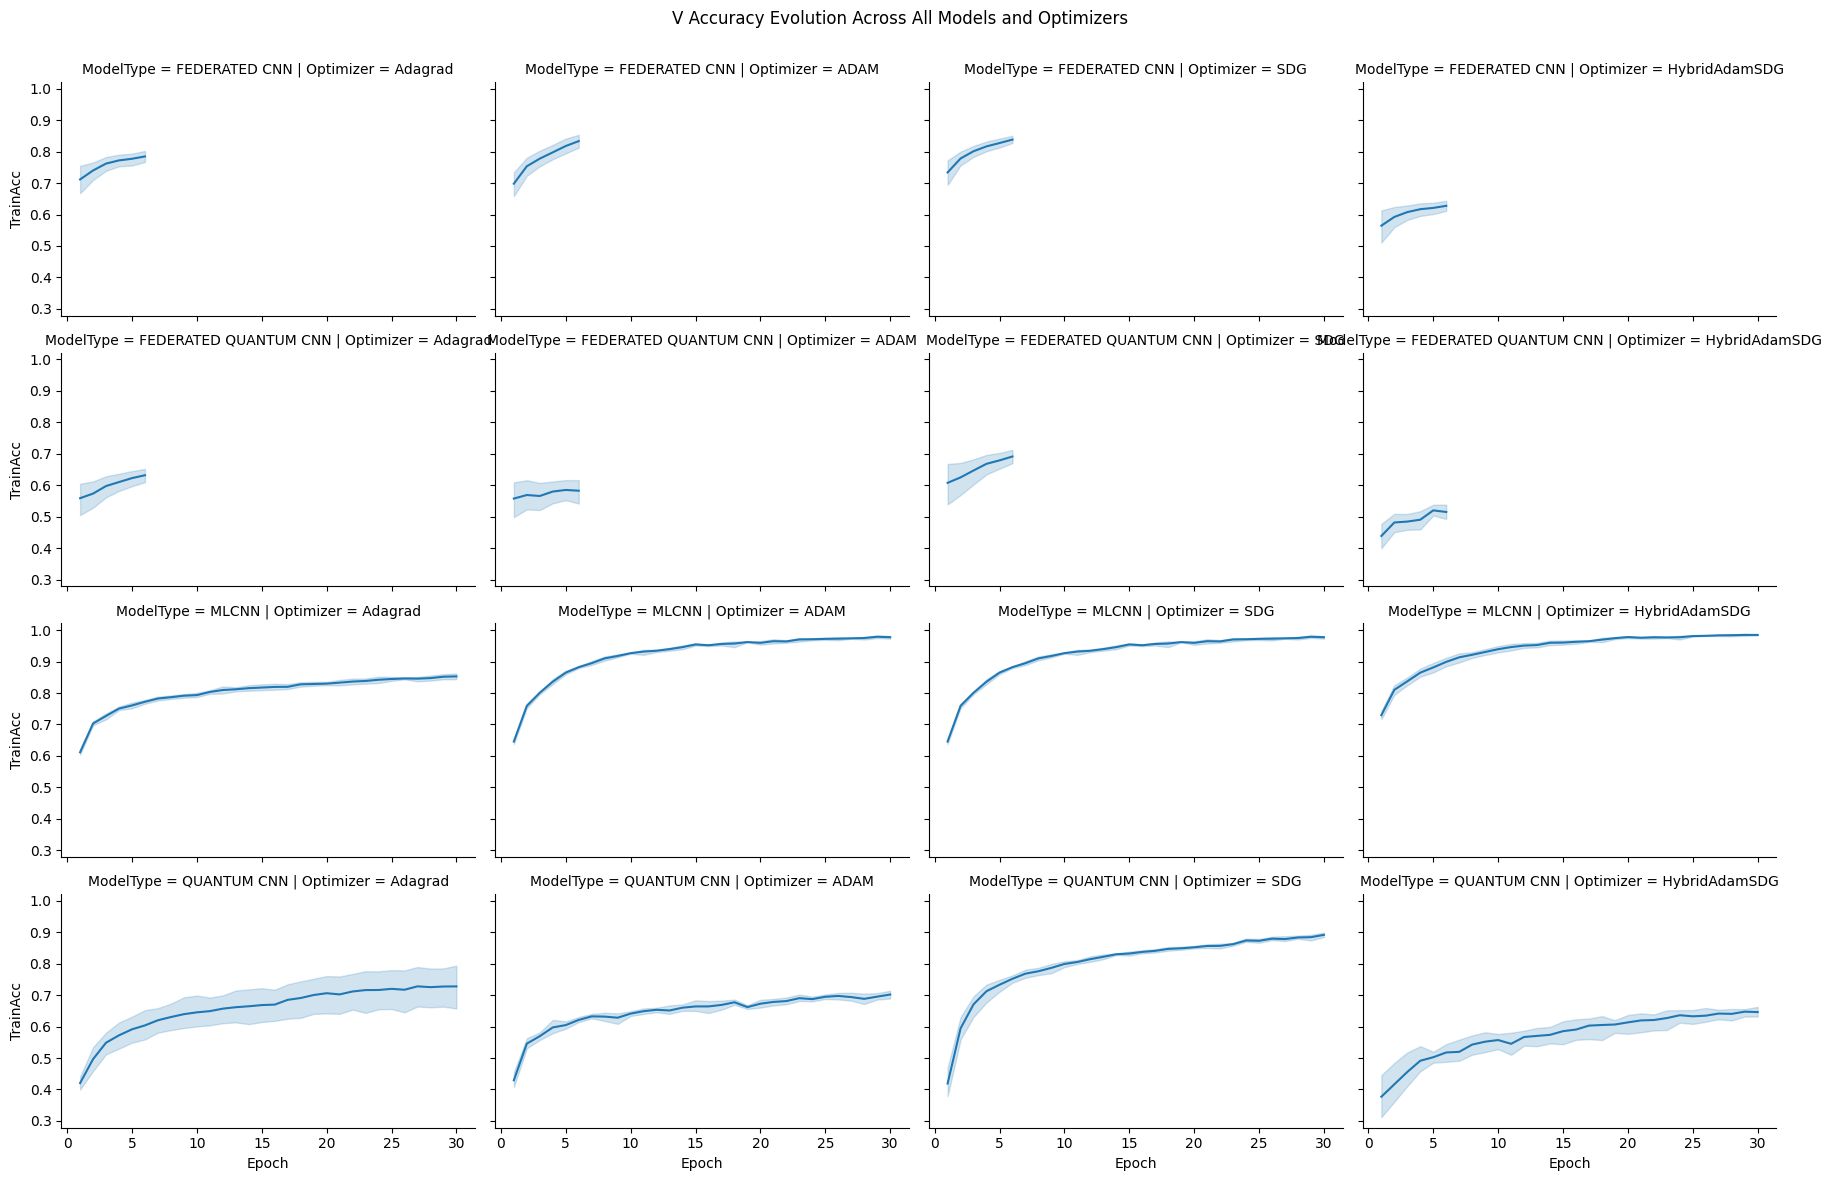

In [9]:
g = sns.FacetGrid(
    df,
    col="Optimizer",
    row="ModelType",
    height=3,
    aspect=1.5
)
g.map(sns.lineplot, "Epoch", "TrainAcc")
g.add_legend()
plt.subplots_adjust(top=0.92)
g.fig.suptitle("V Accuracy Evolution Across All Models and Optimizers")
g.savefig(OUT_DIR/"facet_accuracy_grid.png", dpi=1200)
plt.show()


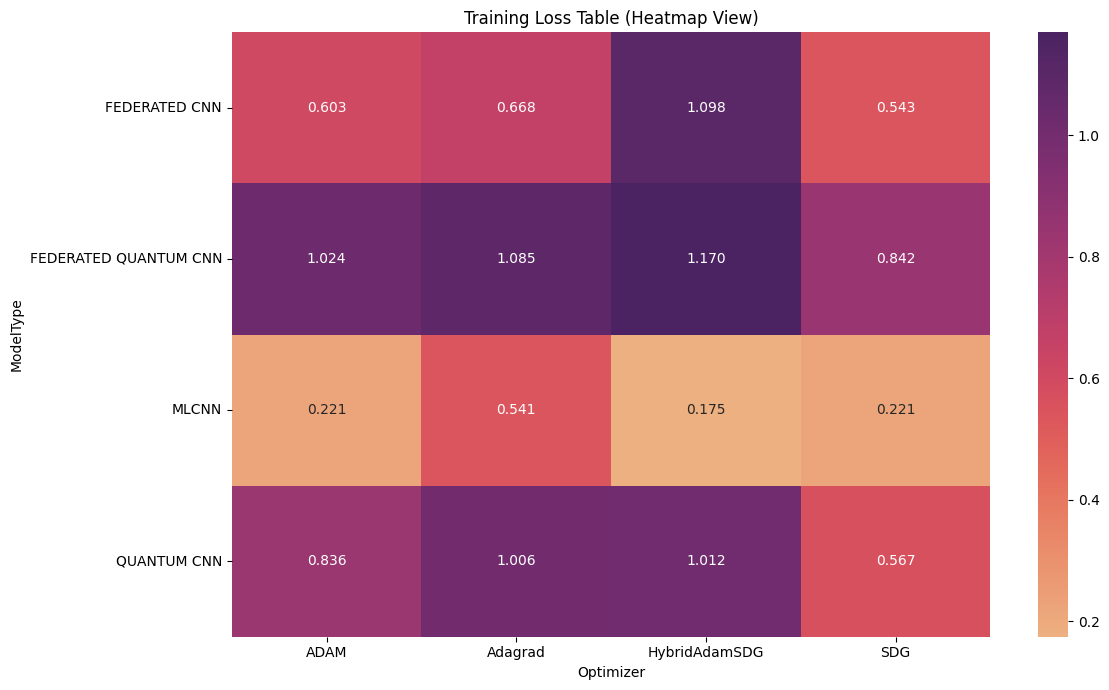

In [10]:
plt.figure(figsize=(12,7))
pivot2 = df.pivot_table(
    values="TrainLoss",
    index="ModelType",
    columns="Optimizer",
    aggfunc="mean"
)

sns.heatmap(pivot2, annot=True, cmap="flare", fmt=".3f")
plt.title("Training Loss Table (Heatmap View)")
plt.tight_layout()
plt.savefig(OUT_DIR/"heatmap_trainloss.png", dpi=1200)
plt.show()


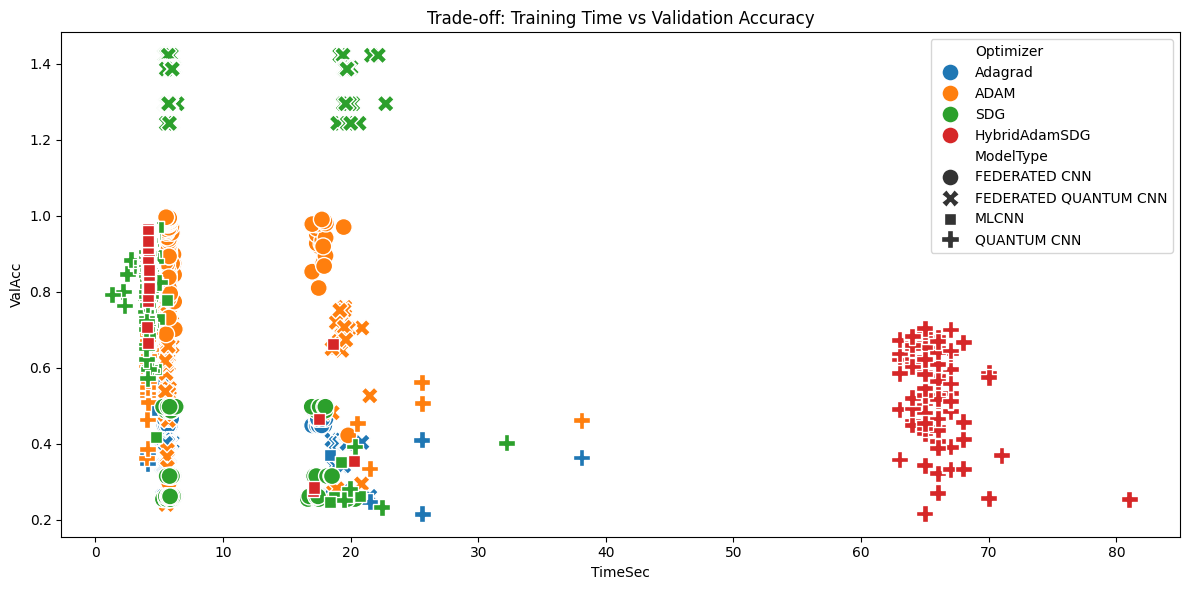

In [11]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df,
    x="TimeSec", y="ValAcc",
    hue="Optimizer",
    style="ModelType",
    s=150
)
plt.title("Trade-off: Training Time vs Validation Accuracy")
plt.tight_layout()
plt.savefig(OUT_DIR/"time_vs_accuracy.png", dpi=1200)
plt.show()


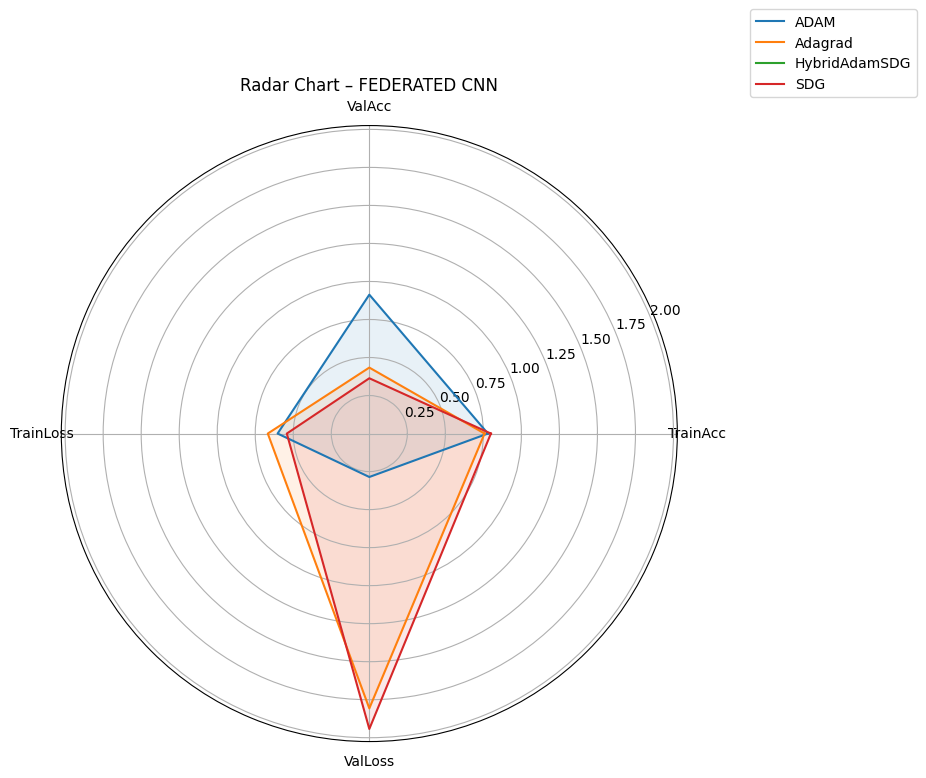

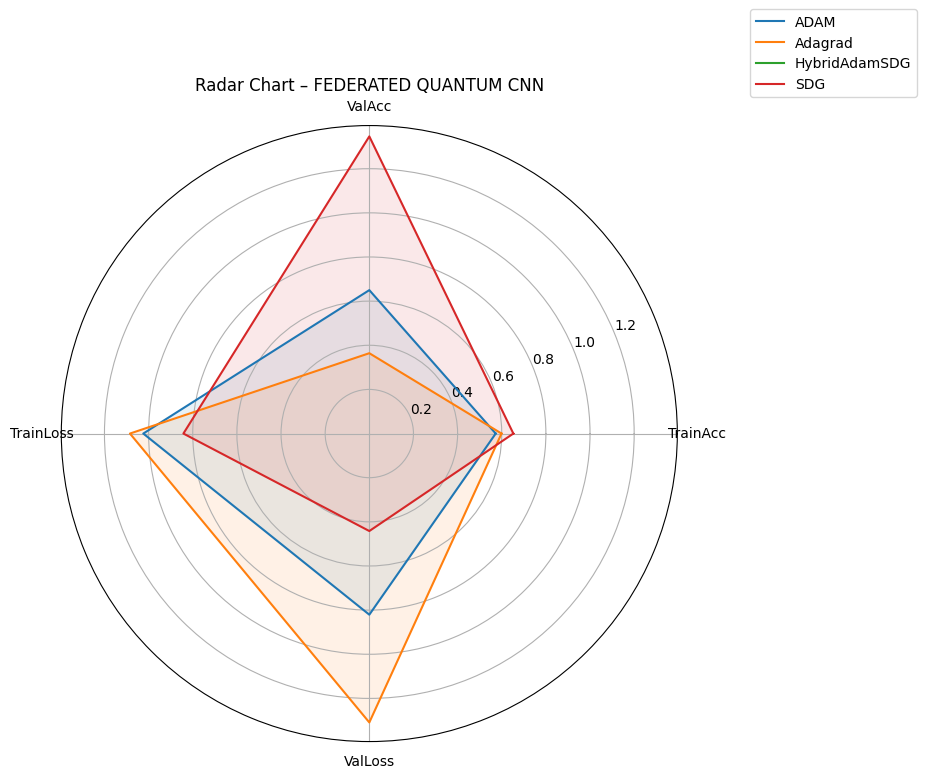

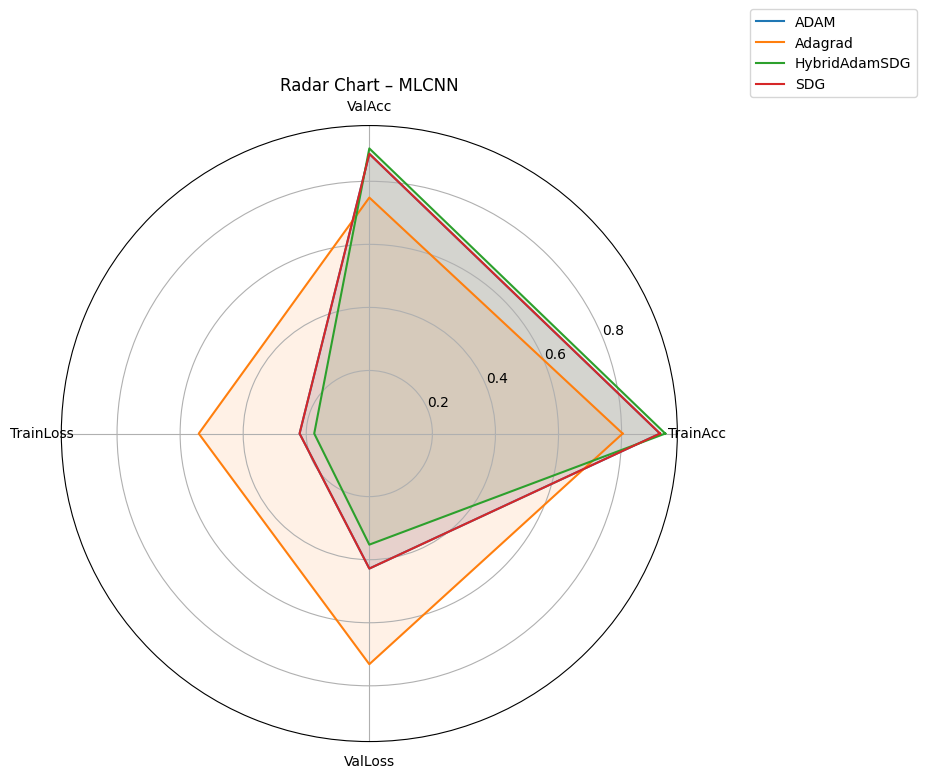

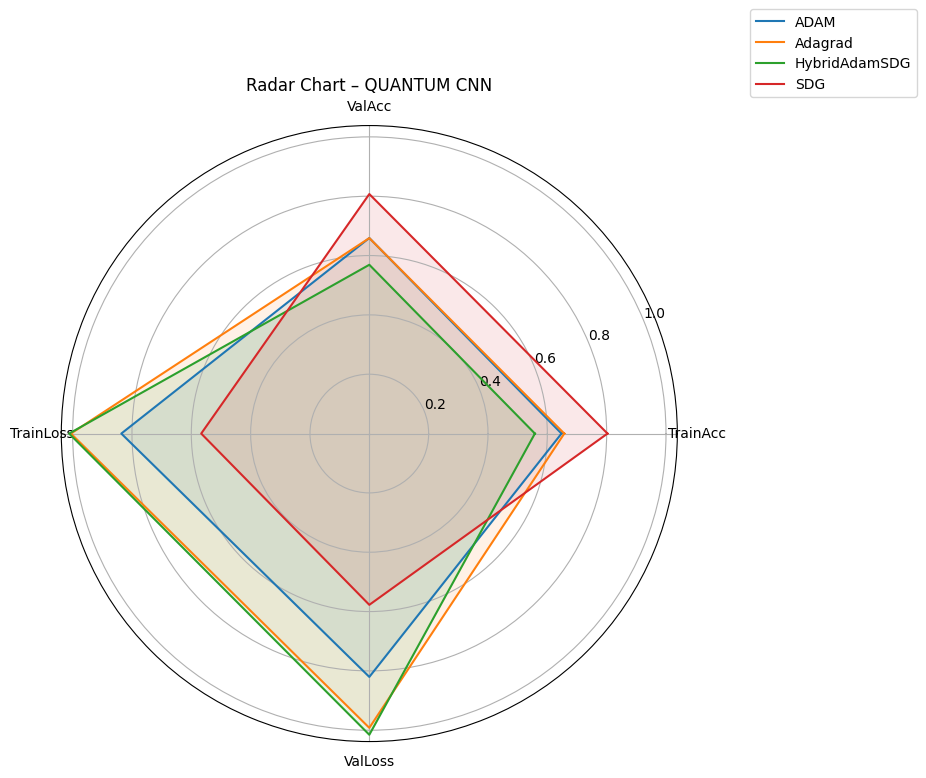

In [12]:
import math

metrics = ["TrainAcc", "ValAcc", "TrainLoss", "ValLoss"]

for model in df["ModelType"].unique():
    sub = df[df["ModelType"] == model].groupby("Optimizer")[metrics].mean()
    labels = sub.index.tolist()
    values = sub.values

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8,8))
    ax = plt.subplot(111, polar=True)

    for i, label in enumerate(labels):
        row = values[i].tolist()
        row += row[:1]
        ax.plot(angles, row, label=label)
        ax.fill(angles, row, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    plt.title(f"Radar Chart – {model}")
    plt.legend(loc="upper right", bbox_to_anchor=(1.4, 1.2))
    plt.savefig(OUT_DIR/f"radar_{model.replace(' ','_')}.png", dpi=1200)
    plt.show()


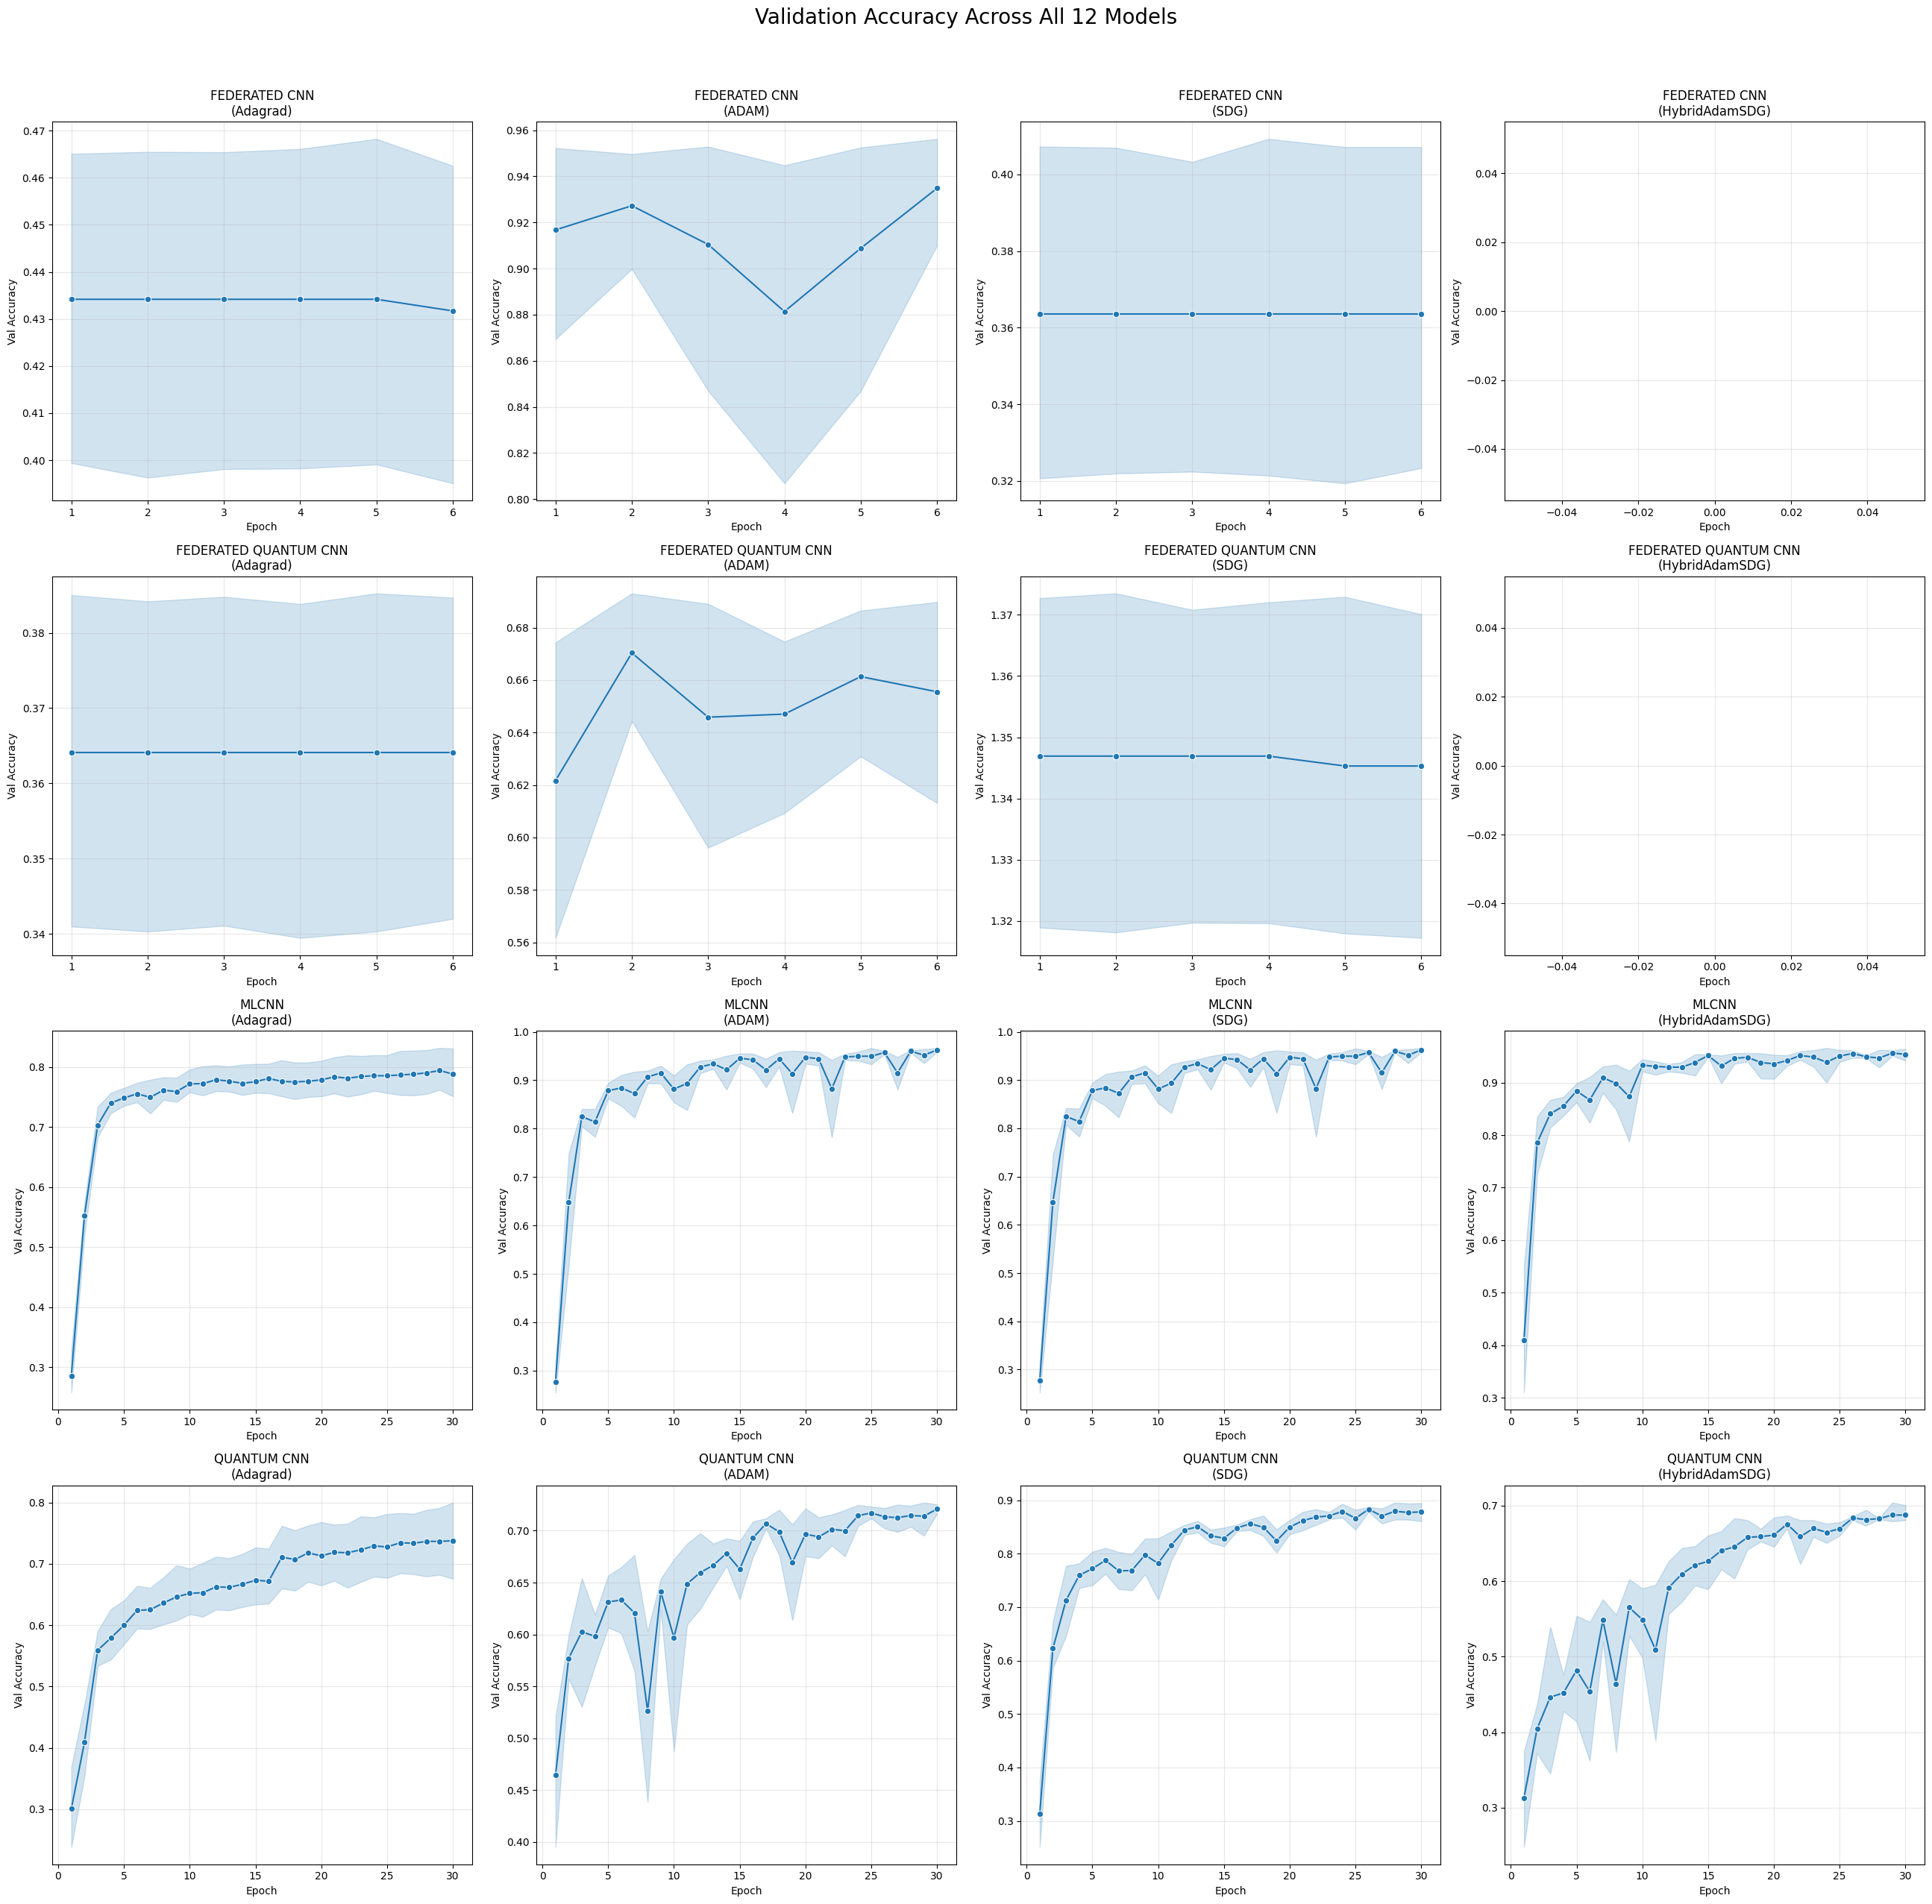

In [13]:


df["Epoch"] = pd.to_numeric(df["Epoch"], errors="coerce")
df["ValAcc"] = pd.to_numeric(df["ValAcc"], errors="coerce")
df["TrainAcc"] = pd.to_numeric(df["TrainAcc"], errors="coerce")
df["ValLoss"] = pd.to_numeric(df["ValLoss"], errors="coerce")
df["TrainLoss"] = pd.to_numeric(df["TrainLoss"], errors="coerce")

models = df["ModelType"].unique()
optimizers = df["Optimizer"].unique()

plt.figure(figsize=(26, 26))
plot_index = 1

for m in models:
    for opt in optimizers:
        sub = df[(df["ModelType"] == m) & (df["Optimizer"] == opt)]
        
        plt.subplot(len(models), len(optimizers), plot_index)
        sns.lineplot(
            data=sub.sort_values("Epoch"),
            x="Epoch",
            y="ValAcc",
            marker="o"
        )
        plt.title(f"{m}\n({opt})", fontsize=12)
        plt.xlabel("Epoch")
        plt.ylabel("Val Accuracy")
        plt.grid(True, alpha=0.3)

        plot_index += 1

plt.suptitle("Validation Accuracy Across All 12 Models", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUT_DIR/"12_models_val_accuracy.png", dpi=1200)
plt.show()


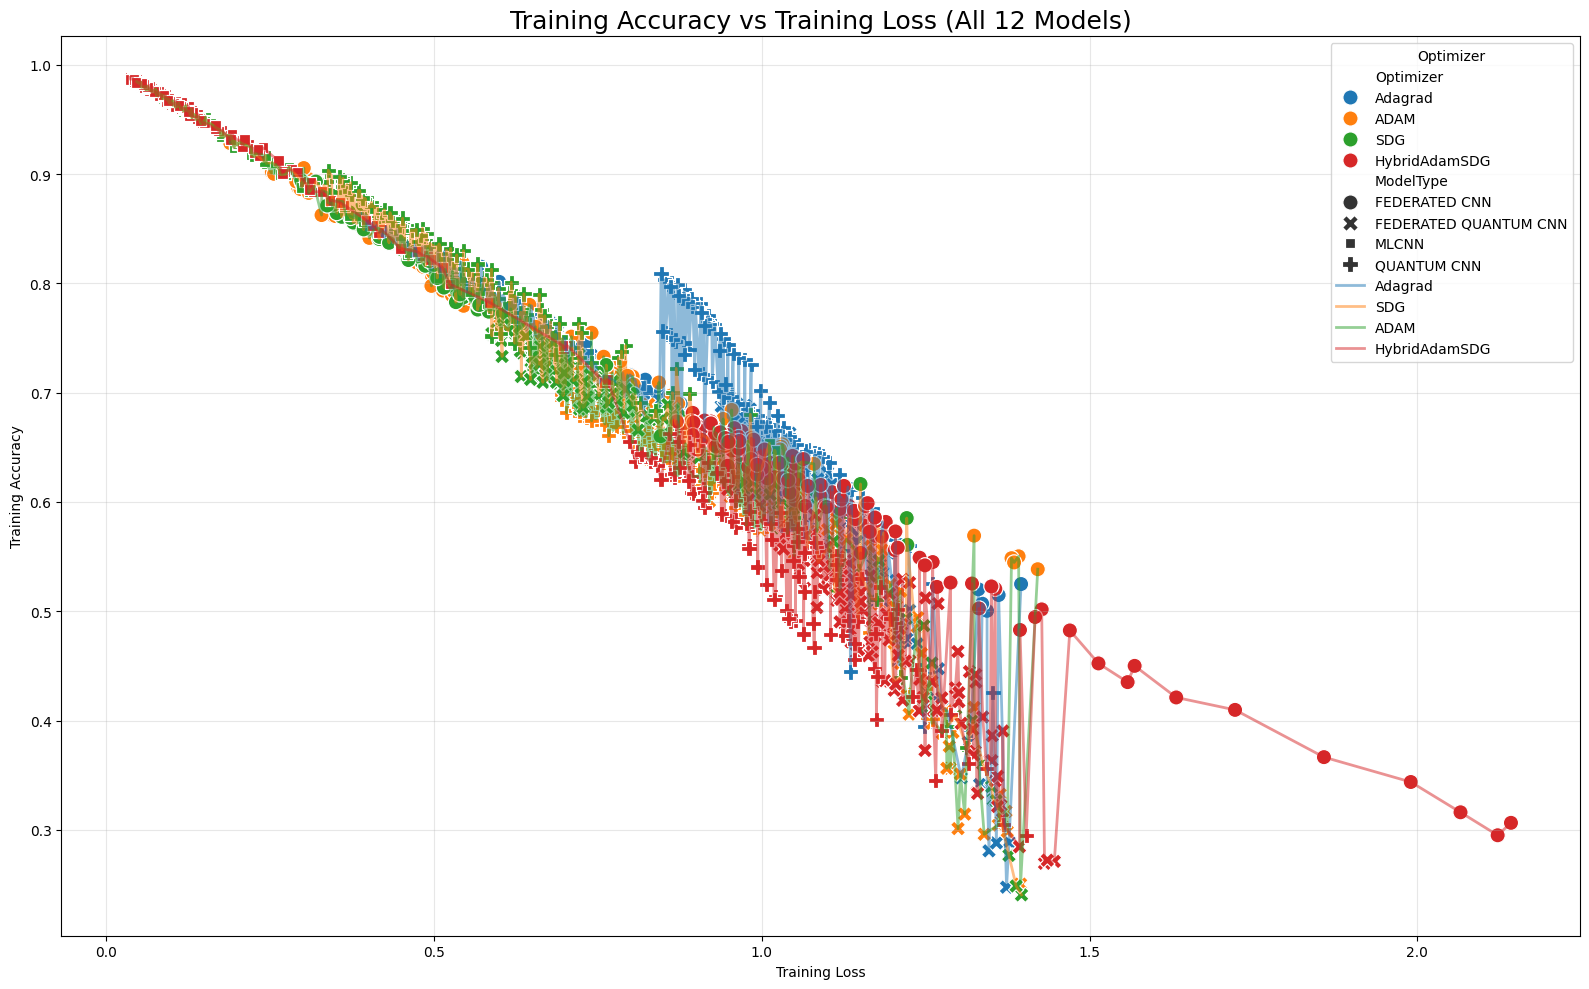

In [14]:
plt.figure(figsize=(16, 10))

sns.scatterplot(
    data=df,
    x="TrainLoss",
    y="TrainAcc",
    hue="Optimizer",
    style="ModelType",
    s=120
)

sns.lineplot(
    data=df.sort_values("Epoch"),
    x="TrainLoss",
    y="TrainAcc",
    hue="Optimizer",
    estimator=None,
    lw=2,
    alpha=0.5
)

plt.title("Training Accuracy vs Training Loss (All 12 Models)", fontsize=18)
plt.xlabel("Training Loss")
plt.ylabel("Training Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/"trainAcc_vs_trainLoss_all12.png", dpi=1200)
plt.show()


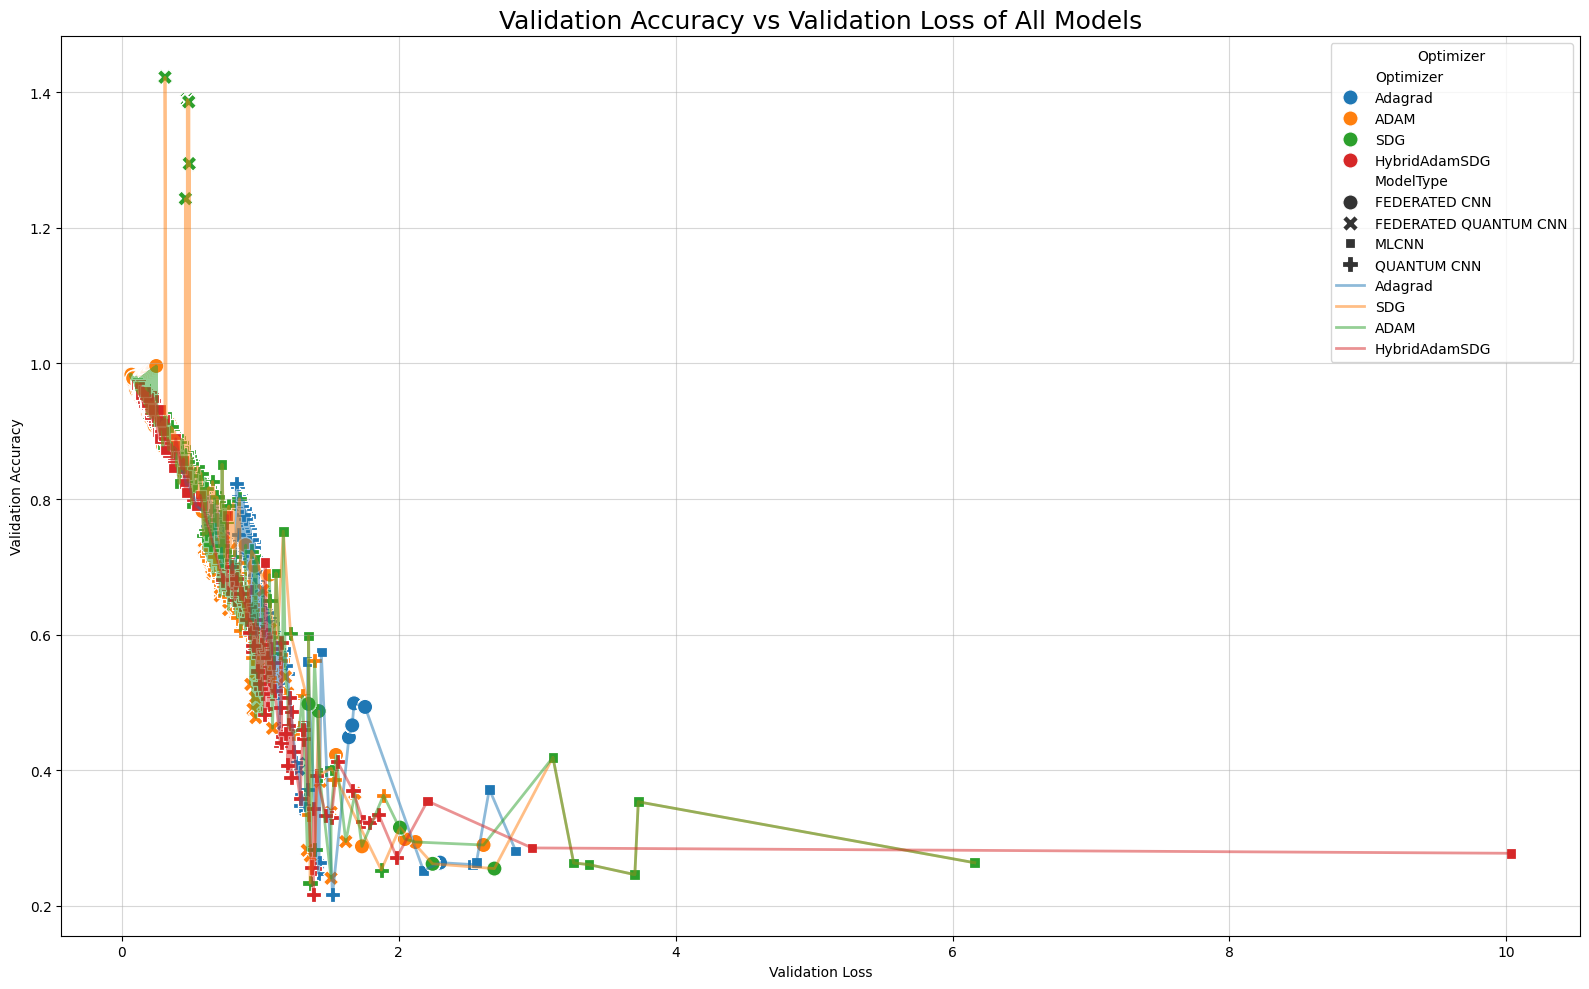

In [15]:
plt.figure(figsize=(16, 10))

sns.scatterplot(
    data=df,
    x="ValLoss",
    y="ValAcc",
    hue="Optimizer",
    style="ModelType",
    s=120
)

sns.lineplot(
    data=df.sort_values("Epoch"),
    x="ValLoss",
    y="ValAcc",
    hue="Optimizer",
    estimator=None,
    lw=2,
    alpha=0.5
)

plt.title("Validation Accuracy vs Validation Loss of All Models", fontsize=18)
plt.xlabel("Validation Loss")
plt.ylabel("Validation Accuracy")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR/"valAcc_vs_valLoss_all12.png", dpi=1200)
plt.show()


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure numeric fields are numeric
num_cols = ["Epoch","TrainAcc","ValAcc","TrainLoss","ValLoss","TimeSec","LR"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


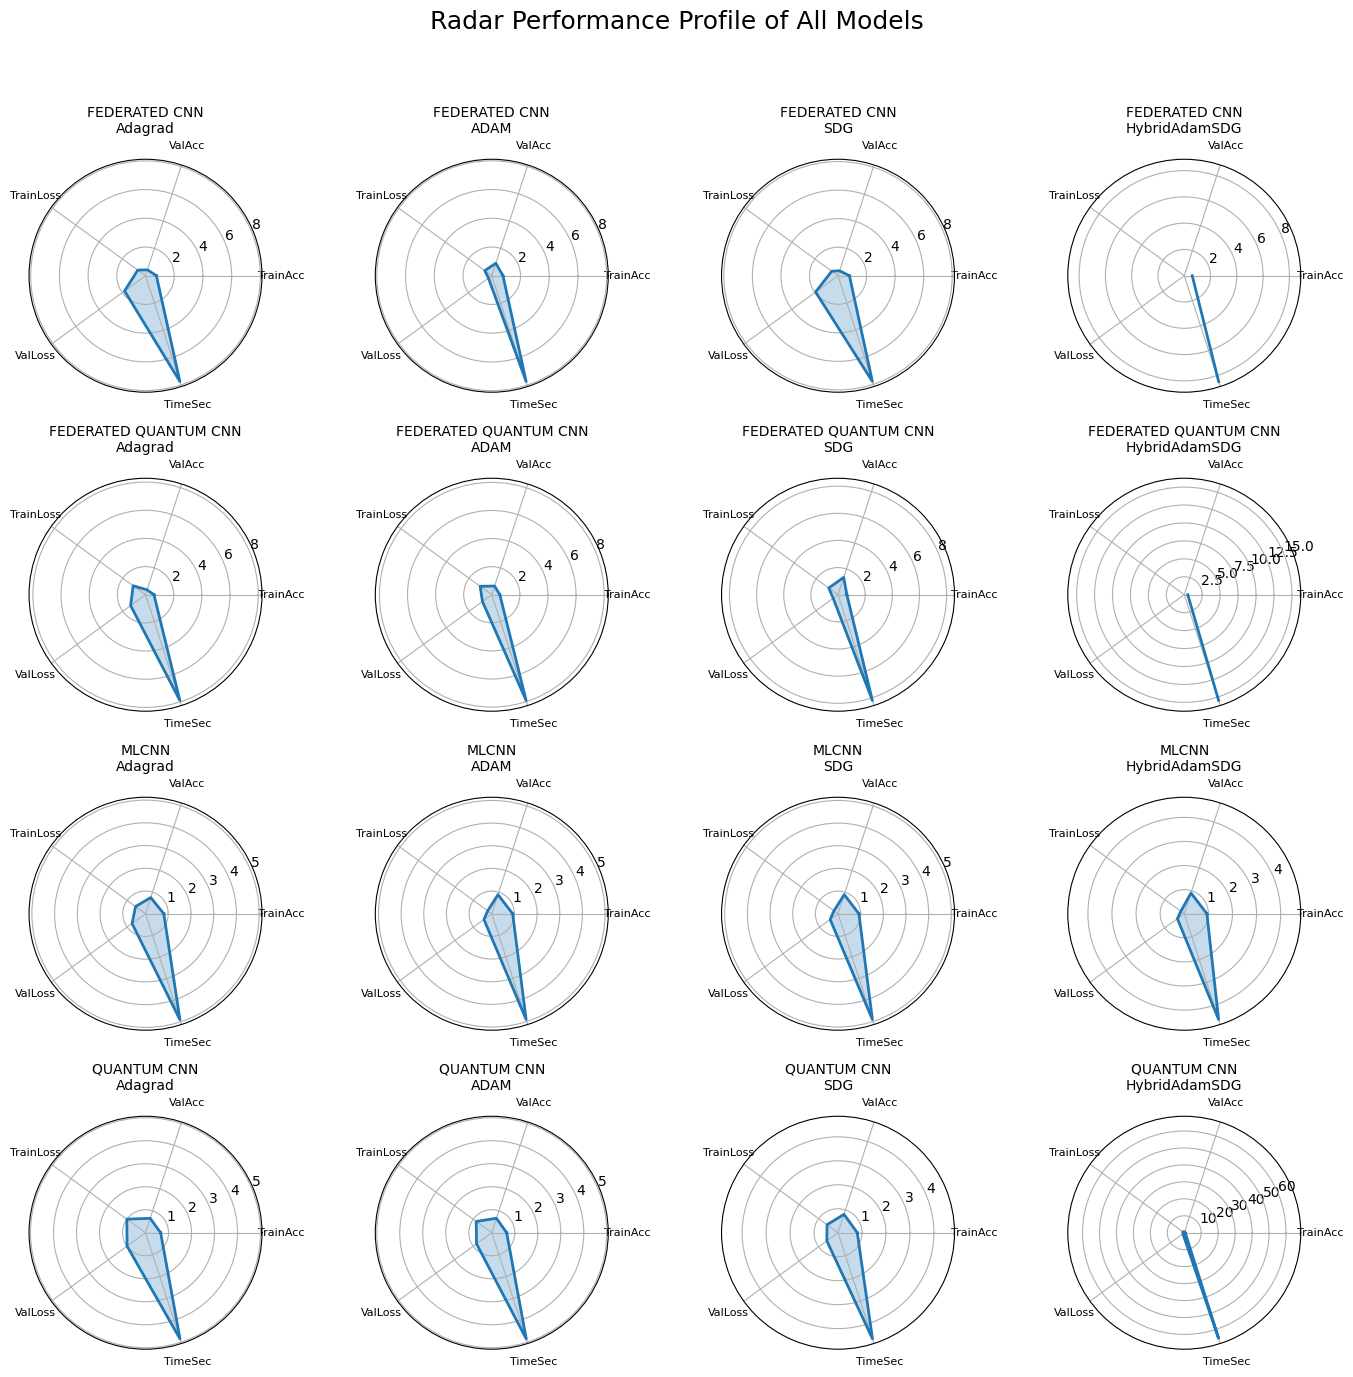

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi

metrics = ["TrainAcc","ValAcc","TrainLoss","ValLoss","TimeSec"]
models = df["ModelType"].unique()
opts = df["Optimizer"].unique()

plt.figure(figsize=(14, 14))

idx = 1
for m in models:
    for o in opts:
        # average only numeric columns
        sub = df[(df["ModelType"]==m) & (df["Optimizer"]==o)].mean(numeric_only=True)

        values = [sub[col] for col in metrics]
        angles = np.linspace(0, 2*pi, len(metrics), endpoint=False).tolist()
        values += values[:1]
        angles += angles[:1]

        ax = plt.subplot(len(models), len(opts), idx, polar=True)
        ax.plot(angles, values, linewidth=2)
        ax.fill(angles, values, alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics, fontsize=8)
        ax.set_title(f"{m}\n{o}", size=10)

        idx += 1

plt.suptitle("Radar Performance Profile of All Models", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUT_DIR/"Radar_Performance_Profile_of_All_Models.png", dpi=1200)
plt.show()


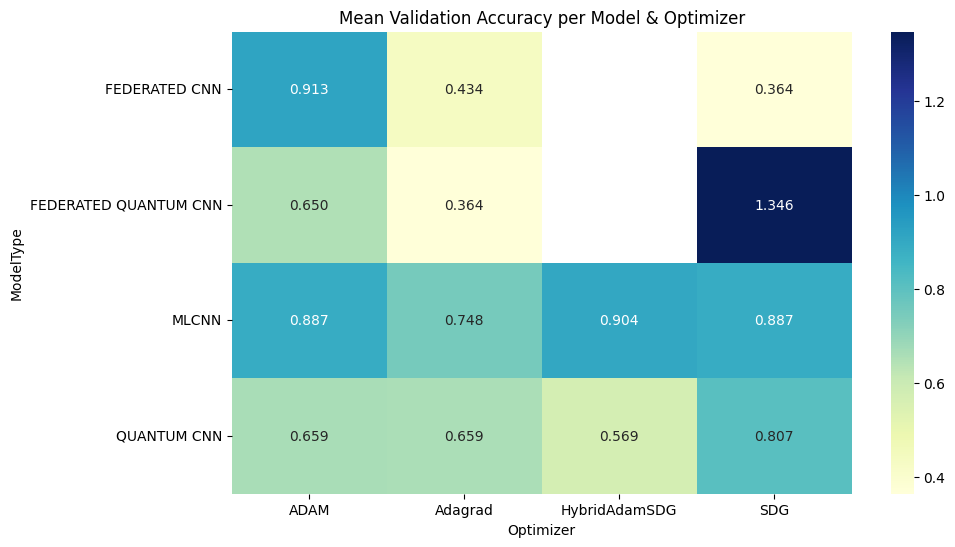

In [18]:
plt.figure(figsize=(10, 6))
pivot = df.groupby(["ModelType","Optimizer"])["ValAcc"].mean().unstack()
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Mean Validation Accuracy per Model & Optimizer")
plt.savefig(OUT_DIR/"mean_valacc_heatmap.png", dpi=1200)
plt.show()


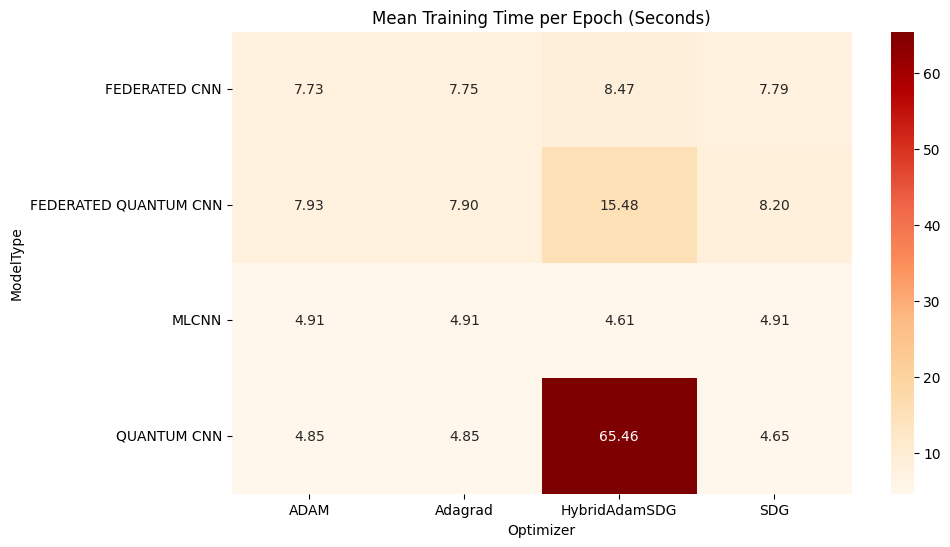

In [19]:
plt.figure(figsize=(10, 6))
pivot = df.groupby(["ModelType","Optimizer"])["TimeSec"].mean().unstack()
sns.heatmap(pivot, annot=True, cmap="OrRd", fmt=".2f")
plt.title("Mean Training Time per Epoch (Seconds)")
plt.savefig(OUT_DIR/"training_time_heatmap.png", dpi=1200)
plt.show()


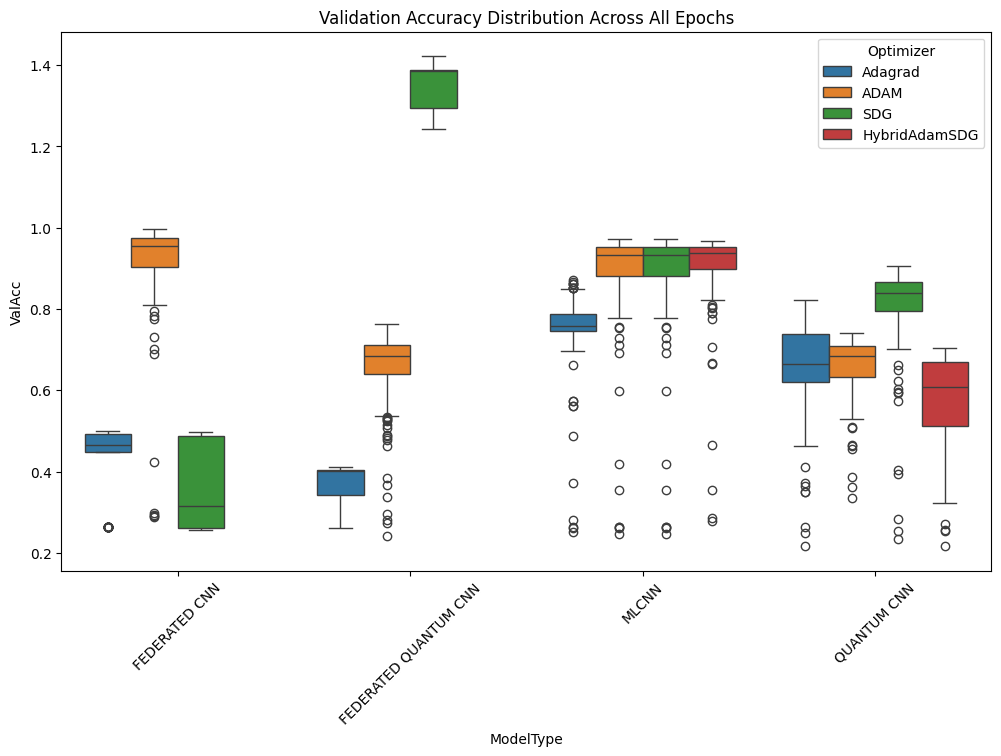

In [20]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x="ModelType", y="ValAcc", hue="Optimizer")
plt.xticks(rotation=45)
plt.title("Validation Accuracy Distribution Across All Epochs")
plt.savefig(OUT_DIR/"valacc_boxplot.png", dpi=1200)
plt.show()


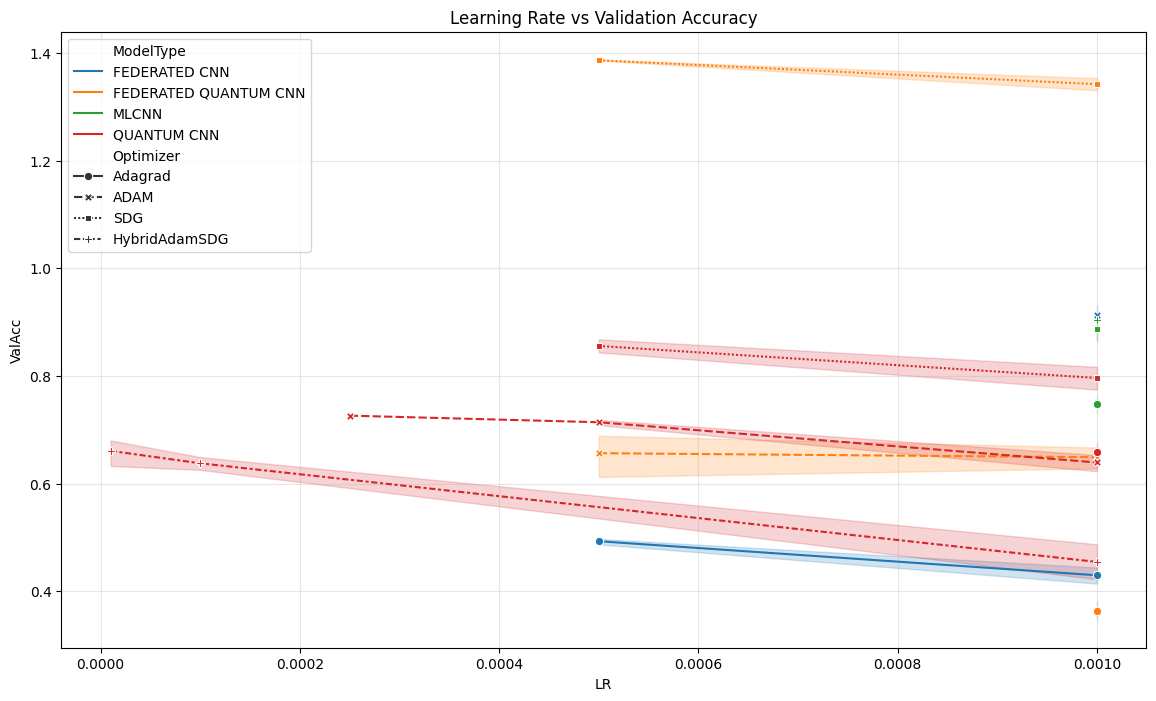

In [21]:
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df,
    x="LR",
    y="ValAcc",
    hue="ModelType",
    style="Optimizer",
    markers=True
)
plt.title("Learning Rate vs Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR/"lr_vs_valacc.png", dpi=1200)
plt.show()


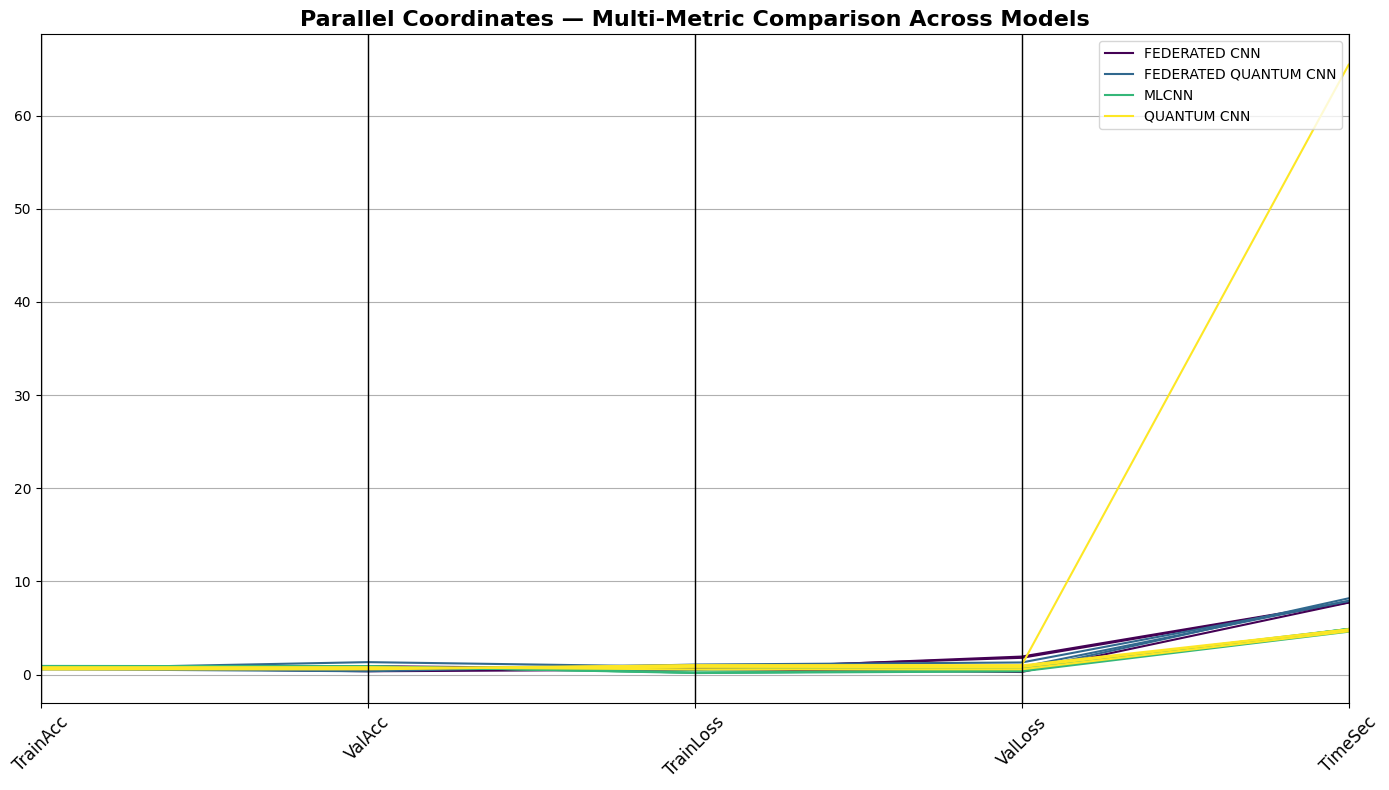

In [22]:
from pandas.plotting import parallel_coordinates

# Group by categorical columns, average only numeric metrics
pc_df = (
    df.groupby(["ModelType","Optimizer"], as_index=False)[
        ["TrainAcc","ValAcc","TrainLoss","ValLoss","TimeSec"]
    ].mean()
)

plt.figure(figsize=(14, 8))
parallel_coordinates(pc_df, "ModelType", cols=["TrainAcc","ValAcc","TrainLoss","ValLoss","TimeSec"], colormap="viridis")

plt.title("Parallel Coordinates — Multi-Metric Comparison Across Models", fontsize=16, fontweight="bold")
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR/"parallel_coordinates.png", dpi=1200)
plt.show()


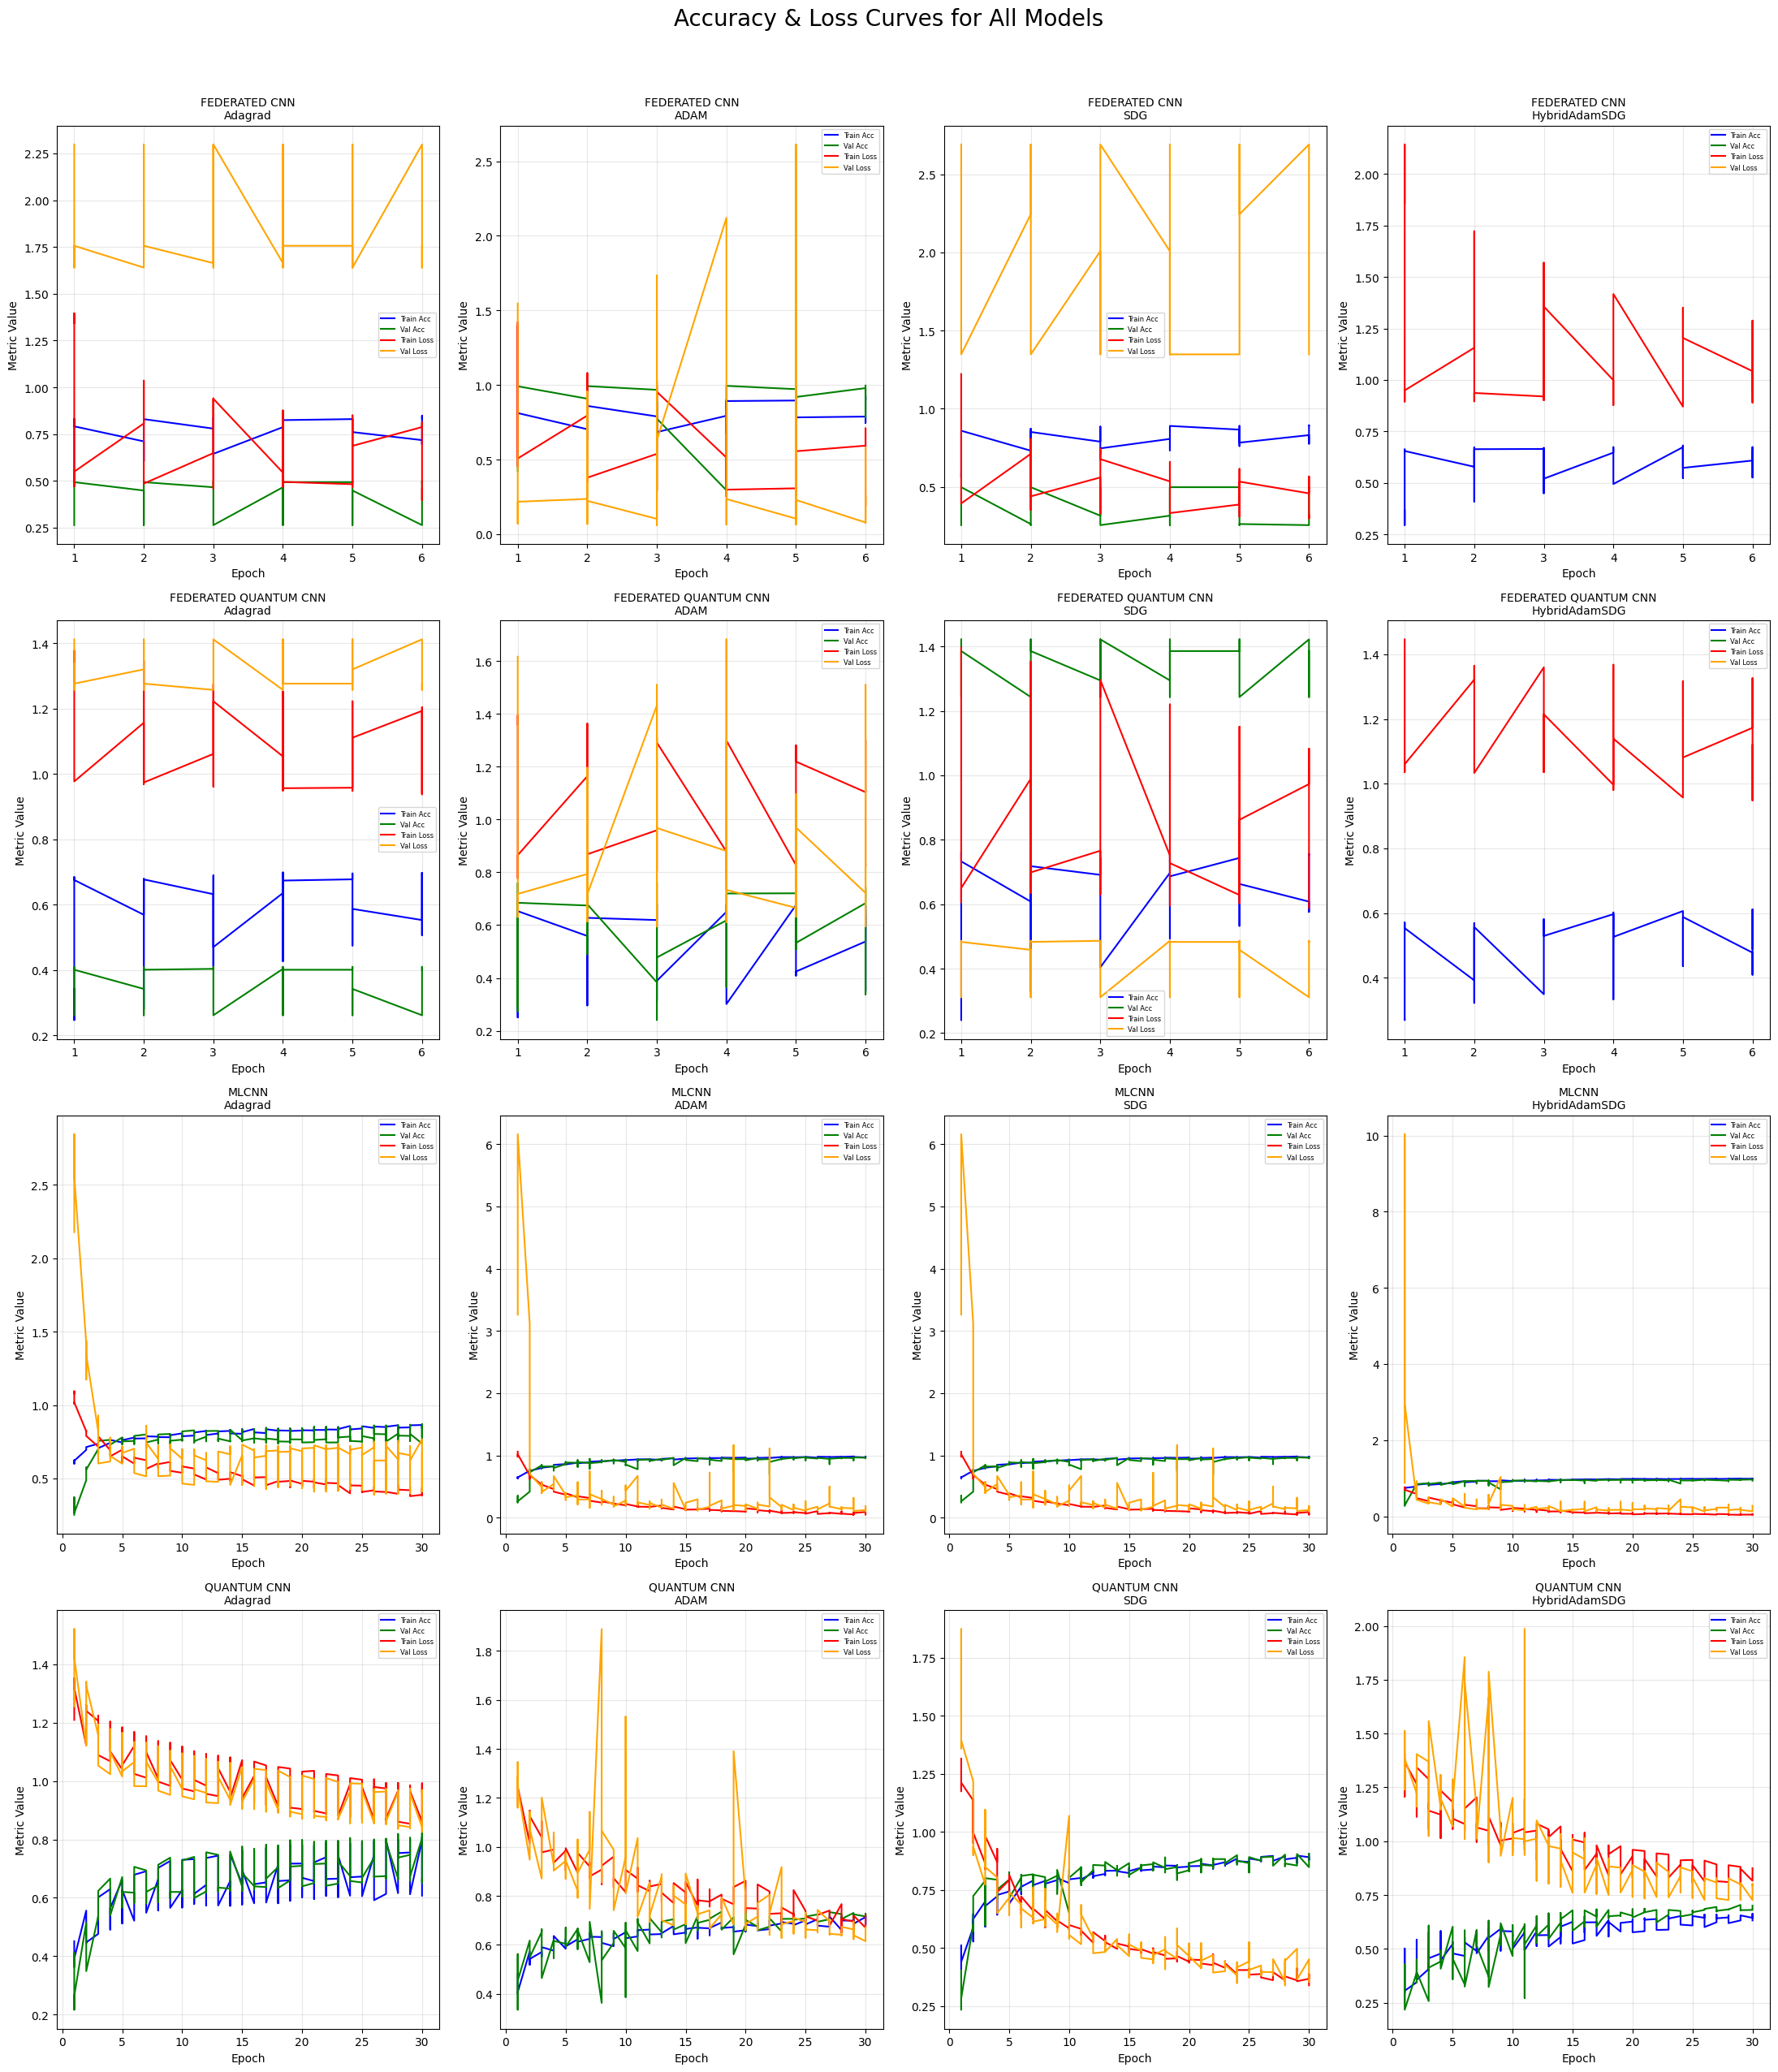

In [23]:
nrows = len(models)
ncols = len(opts)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(22, 26))

for i, m in enumerate(models):
    for j, o in enumerate(opts):
        sub = df[(df["ModelType"]==m) & (df["Optimizer"]==o)].sort_values("Epoch")
        ax = axes[i, j]

        ax.plot(sub["Epoch"], sub["TrainAcc"], label="Train Acc", color="blue")
        ax.plot(sub["Epoch"], sub["ValAcc"], label="Val Acc", color="green")
        ax.plot(sub["Epoch"], sub["TrainLoss"], label="Train Loss", color="red")
        ax.plot(sub["Epoch"], sub["ValLoss"], label="Val Loss", color="orange")

        ax.set_title(f"{m}\n{o}", fontsize=10)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Metric Value")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=6)

plt.suptitle("Accuracy & Loss Curves for All Models", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUT_DIR/"all_training_curves.png", dpi=1200)
plt.show()


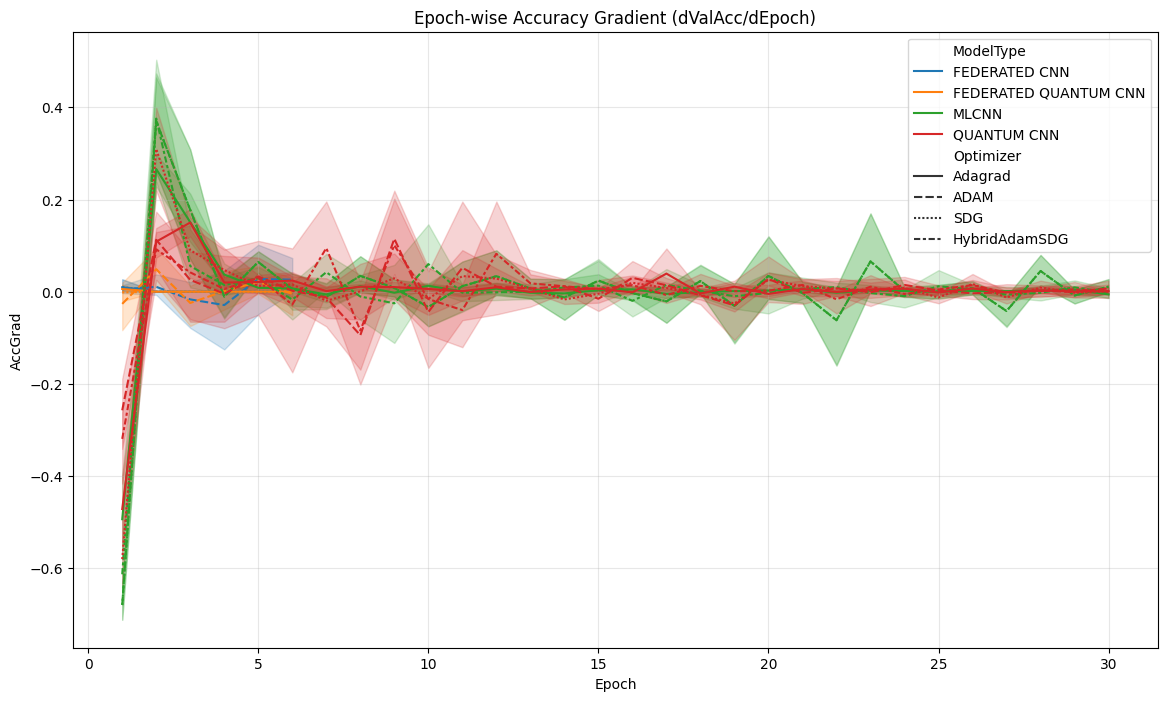

In [24]:
df["AccGrad"] = df.groupby(["ModelType","Optimizer"])["ValAcc"].diff()

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df,
    x="Epoch",
    y="AccGrad",
    hue="ModelType",
    style="Optimizer"
)
plt.title("Epoch-wise Accuracy Gradient (dValAcc/dEpoch)")
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR/"accuracy_gradient.png", dpi=1200)
plt.show()


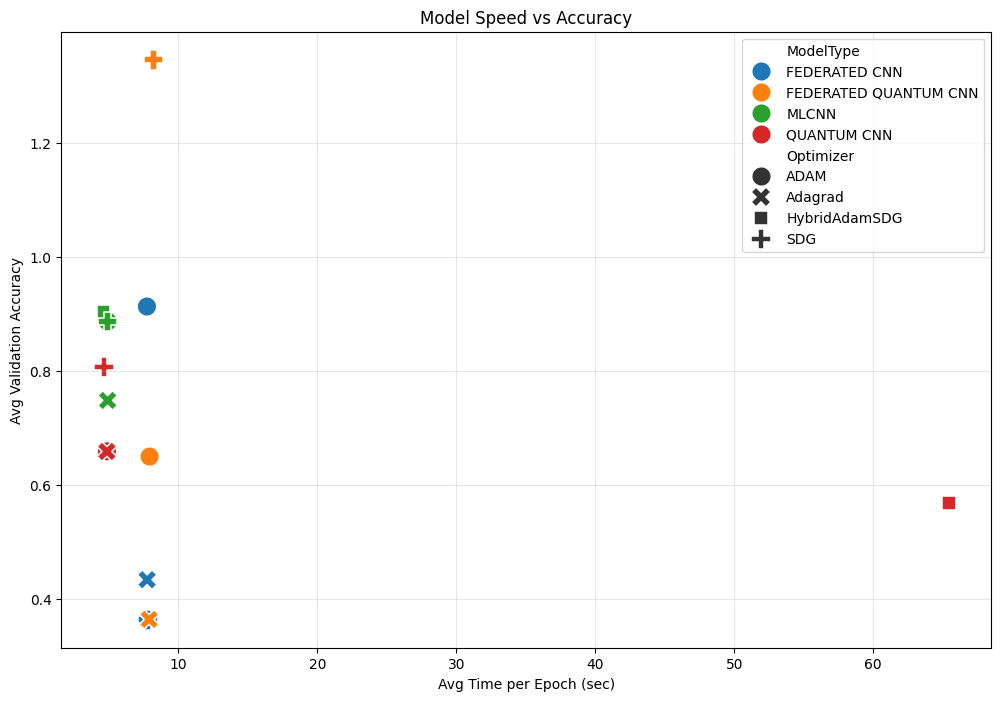

In [25]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df.groupby(["ModelType","Optimizer"]).mean().reset_index(),
    x="TimeSec",
    y="ValAcc",
    hue="ModelType",
    style="Optimizer",
    s=200
)
plt.title("Model Speed vs Accuracy")
plt.xlabel("Avg Time per Epoch (sec)")
plt.ylabel("Avg Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR/"speed_vs_accuracy.png", dpi=1200)
plt.show()


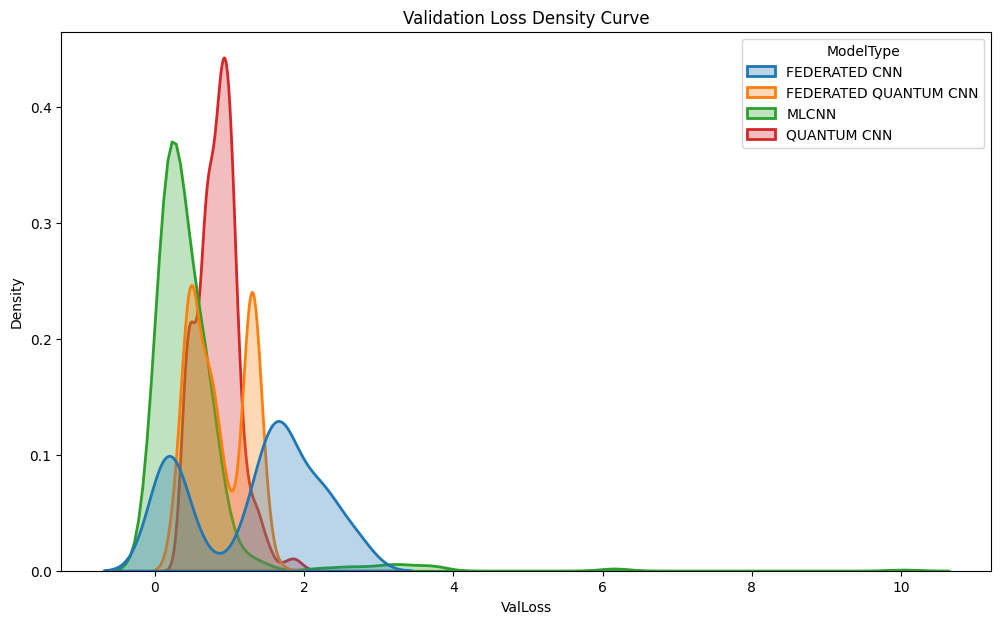

In [26]:
plt.figure(figsize=(12, 7))
sns.kdeplot(
    data=df,
    x="ValLoss",
    hue="ModelType",
    fill=True,
    alpha=0.3,
    linewidth=2
)
plt.title("Validation Loss Density Curve")
plt.savefig(OUT_DIR/"val_loss_density.png", dpi=1200)
plt.show()


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df=pd.read_csv("/mnt/c/Users/hassa/OneDrive/Desktop/QML/FINAL_RESEARCH_DATA.csv")

# Clean numeric columns
num_cols = ["Epoch","TrainAcc","ValAcc","TrainLoss","ValLoss","TimeSec","LR"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

sns.set(style="whitegrid", font_scale=1.2)


/tmp/ipykernel_10836/3241029972.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


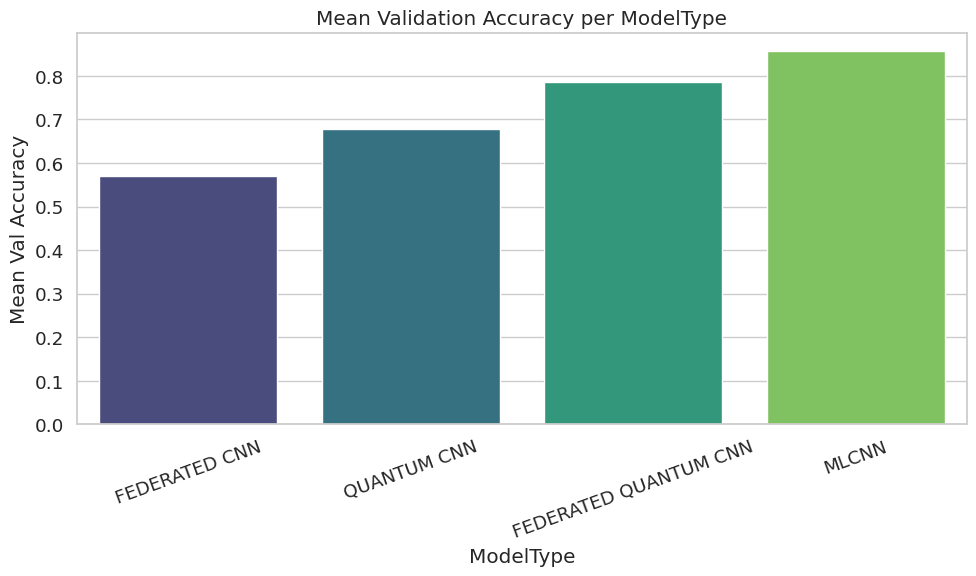

In [28]:
plt.figure(figsize=(10,6))
mean_acc = df.groupby("ModelType")["ValAcc"].mean().sort_values()

sns.barplot(
    x=mean_acc.index,
    y=mean_acc.values,
    palette="viridis"
)

plt.title("Mean Validation Accuracy per ModelType")
plt.ylabel("Mean Val Accuracy")
plt.xlabel("ModelType")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUT_DIR/"modeltype_mean_valacc.png", dpi=1200)
plt.show()


/tmp/ipykernel_10836/754831326.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


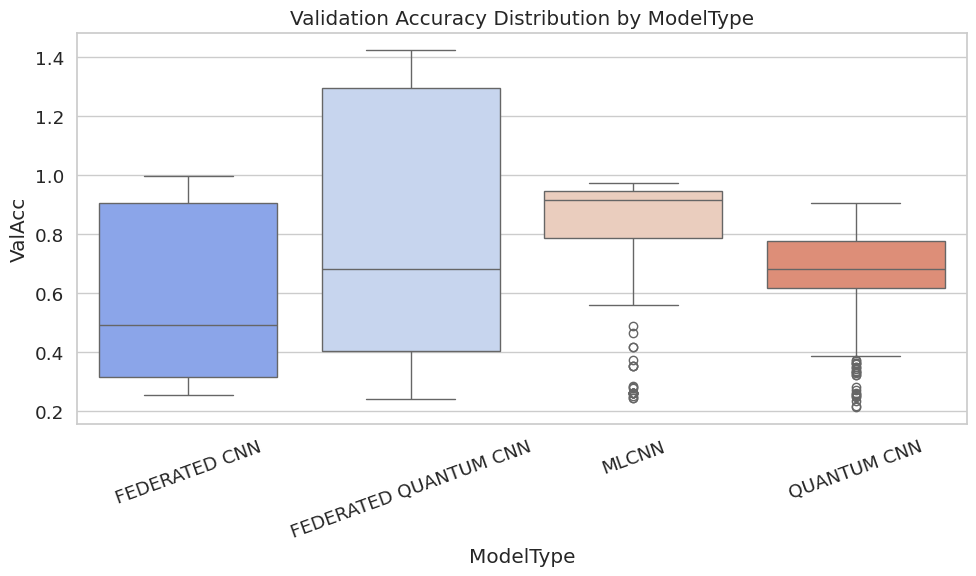

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="ModelType",
    y="ValAcc",
    palette="coolwarm"
)
plt.title("Validation Accuracy Distribution by ModelType")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUT_DIR/"modeltype_accuracy_boxplot.png", dpi=1200)
plt.show()


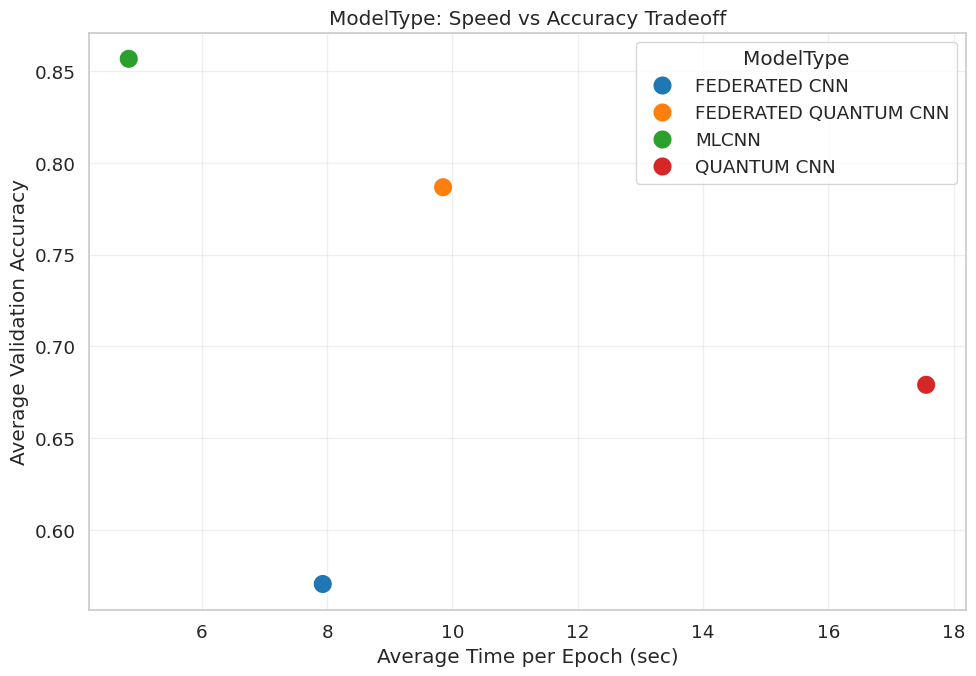

In [30]:
plt.figure(figsize=(10,7))
grouped = df.groupby("ModelType")[["ValAcc","TimeSec"]].mean().reset_index()

sns.scatterplot(
    data=grouped,
    x="TimeSec",
    y="ValAcc",
    hue="ModelType",
    s=200,
    palette="tab10"
)
plt.title("ModelType: Speed vs Accuracy Tradeoff")
plt.xlabel("Average Time per Epoch (sec)")
plt.ylabel("Average Validation Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/"modeltype_speed_vs_accuracy.png", dpi=1200)
plt.show()


/tmp/ipykernel_10836/792391808.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


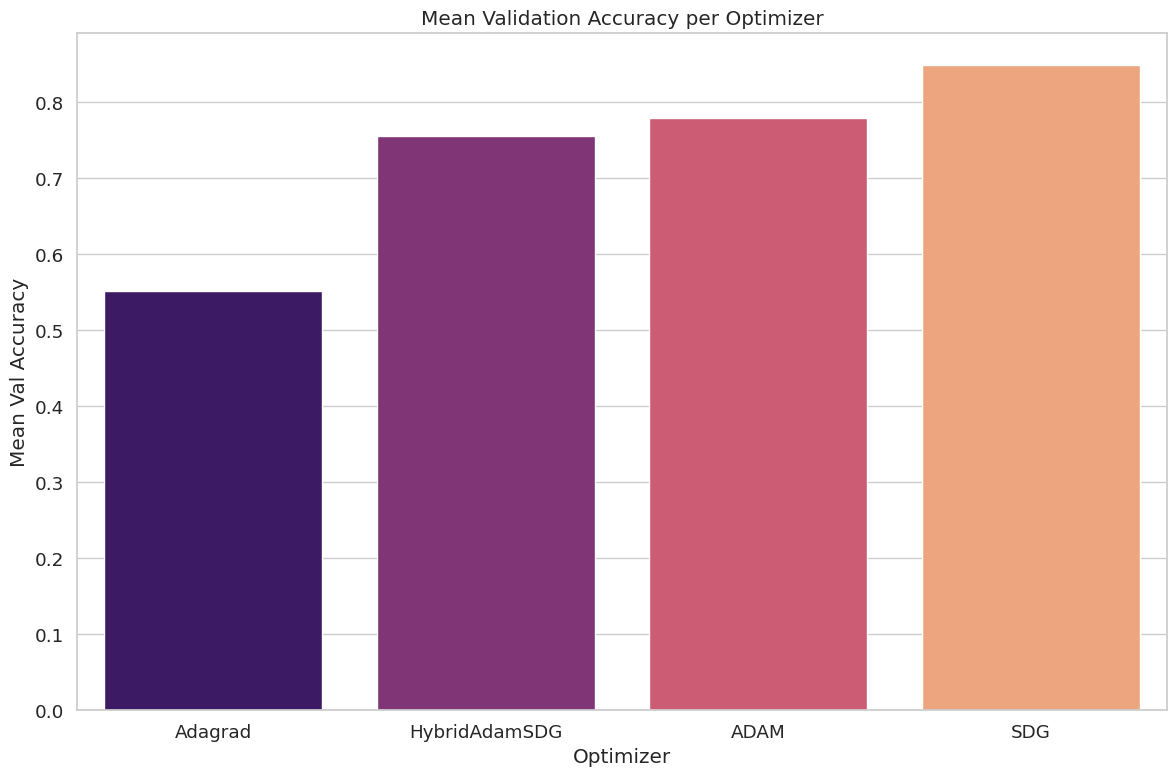

In [31]:
plt.figure(figsize=(12,8))
acc_opt = df.groupby("Optimizer")["ValAcc"].mean().sort_values()

sns.barplot(
    x=acc_opt.index,
    y=acc_opt.values,
    palette="magma"
)

plt.title("Mean Validation Accuracy per Optimizer")
plt.ylabel("Mean Val Accuracy")
plt.xlabel("Optimizer")
plt.tight_layout()
plt.savefig(OUT_DIR/"optimizer_mean_valacc.png", dpi=1200)
plt.show()


/tmp/ipykernel_10836/4028292411.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


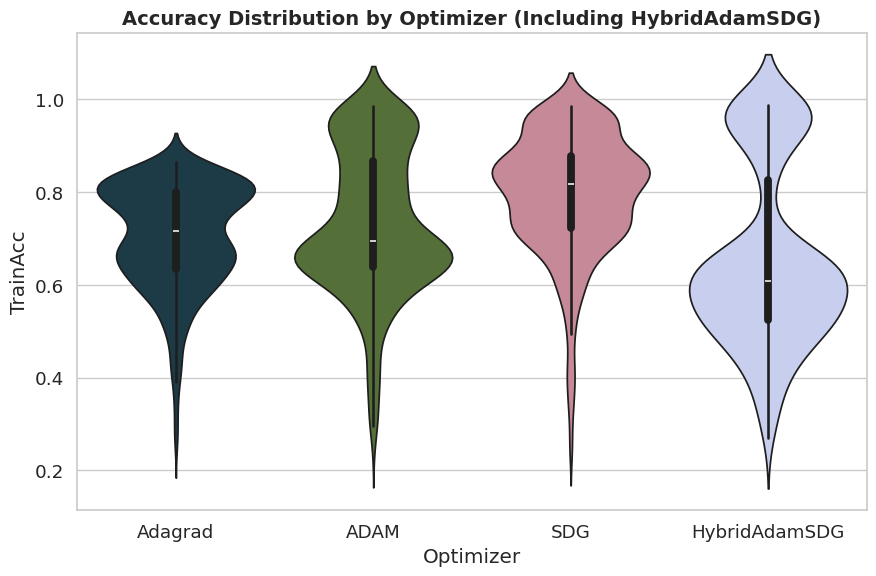

In [32]:
plt.figure(figsize=(9,6))
sns.violinplot(
    data=df[df["Optimizer"].isin(["ADAM","Adagrad","SDG","HybridAdamSDG"])],
    x="Optimizer",
    y="TrainAcc",
    palette="cubehelix"
)
plt.title("Accuracy Distribution by Optimizer (Including HybridAdamSDG)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR/"optimizer_accuracy_violin.png", dpi=1200)
plt.show()


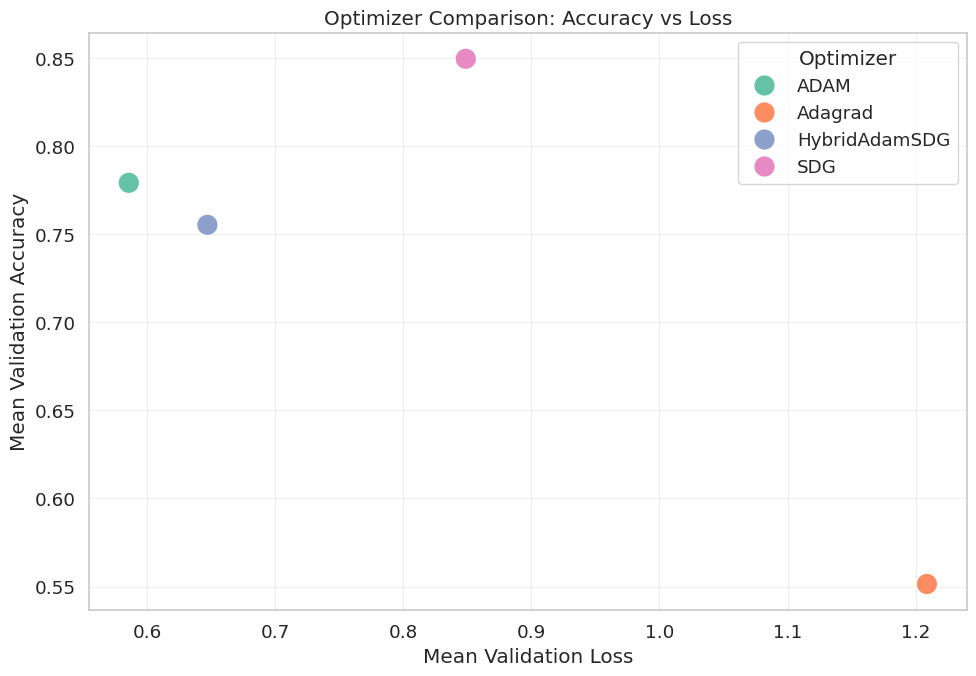

In [33]:
plt.figure(figsize=(10,7))

opt_means = df.groupby("Optimizer")[["ValAcc","ValLoss"]].mean().reset_index()

sns.scatterplot(
    data=opt_means,
    x="ValLoss",
    y="ValAcc",
    hue="Optimizer",
    s=250,
    palette="Set2"
)
plt.title("Optimizer Comparison: Accuracy vs Loss")
plt.xlabel("Mean Validation Loss")
plt.ylabel("Mean Validation Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/"optimizer_loss_vs_acc.png", dpi=1200)
plt.show()


In [34]:
import pandas as pd

df=pd.read_csv("/mnt/c/Users/hassa/OneDrive/Desktop/QML/FINAL_RESEARCH_DATA.csv")

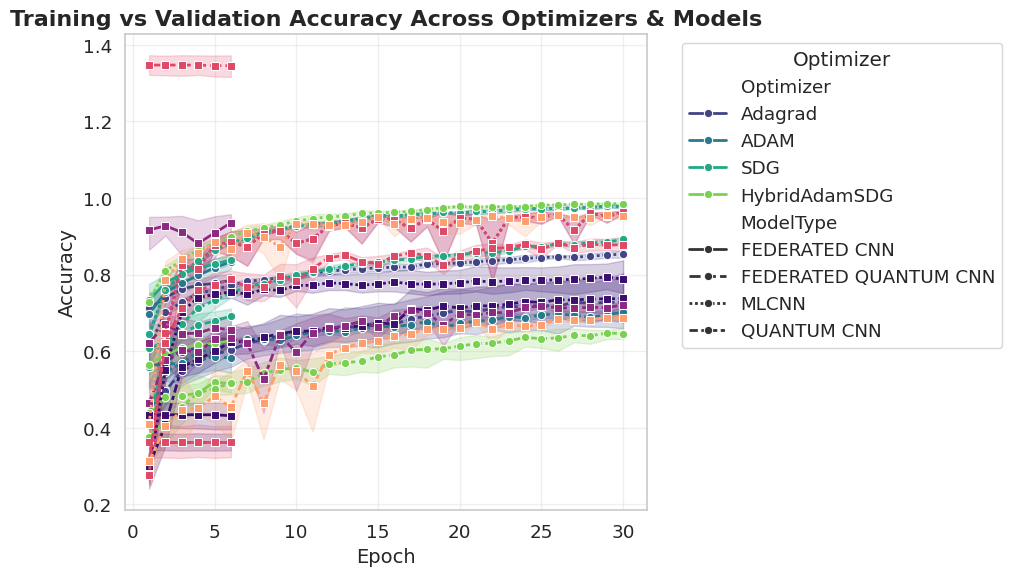

In [35]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Epoch', y='TrainAcc', hue='Optimizer',
             style='ModelType', marker='o', palette='viridis', linewidth=2)
sns.lineplot(data=df, x='Epoch', y='ValAcc', hue='Optimizer',
             style='ModelType', marker='s', palette='magma', linewidth=2, linestyle='--', legend=False)

plt.title("Training vs Validation Accuracy Across Optimizers & Models", fontsize=16, fontweight='bold')
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(title='Optimizer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR/"Training_vs_Validation_Accuracy_Across_Optimizers_and_Models.png", dpi=1200)
plt.show()


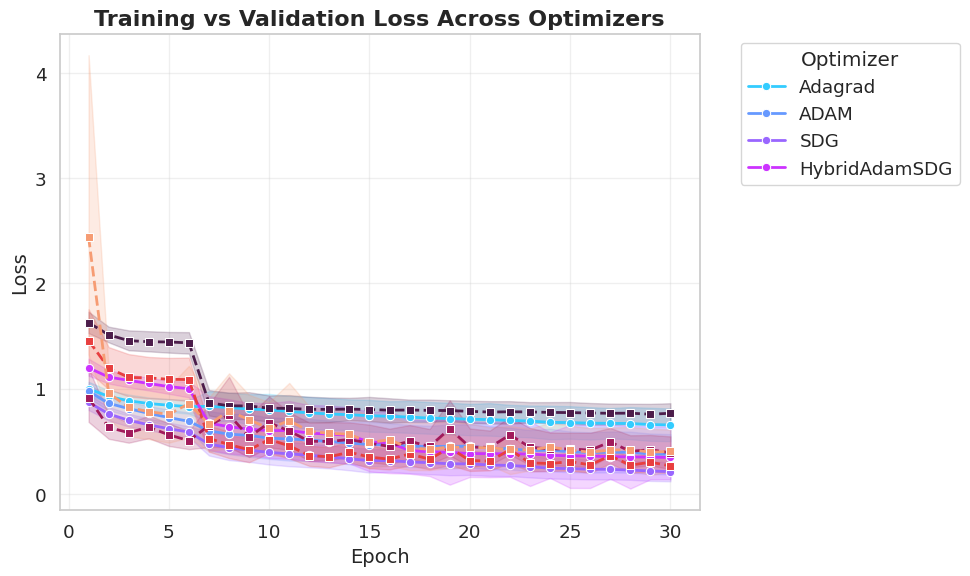

In [36]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Epoch', y='TrainLoss', hue='Optimizer',
             marker='o', palette='cool', linewidth=2)
sns.lineplot(data=df, x='Epoch', y='ValLoss', hue='Optimizer',
             marker='s', palette='rocket', linewidth=2, linestyle='--', legend=False)

plt.title("Training vs Validation Loss Across Optimizers", fontsize=16, fontweight='bold')
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(title='Optimizer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR/"Training_vs_Validation_Loss_Across_Optimizers.png", dpi=1200)
plt.show()


/tmp/ipykernel_10836/3016043217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Epoch']==df['Epoch'].max()],


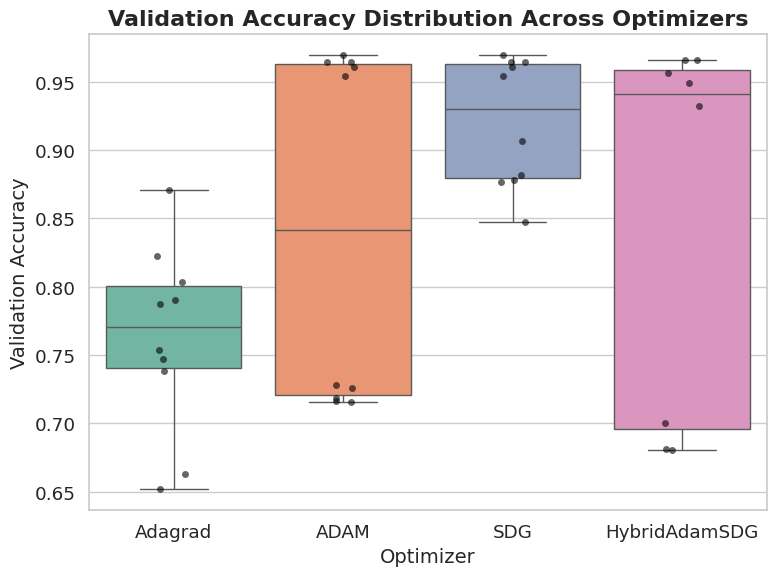

In [37]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df[df['Epoch']==df['Epoch'].max()],
            x='Optimizer', y='ValAcc', palette='Set2')
sns.stripplot(data=df[df['Epoch']==df['Epoch'].max()],
              x='Optimizer', y='ValAcc', color='black', alpha=0.6)

plt.title("Validation Accuracy Distribution Across Optimizers", fontsize=16, fontweight='bold')
plt.xlabel("Optimizer", fontsize=14)
plt.ylabel("Validation Accuracy", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR/"Validation_Accuracy_Across_Optimizers.png", dpi=1200)
plt.show()


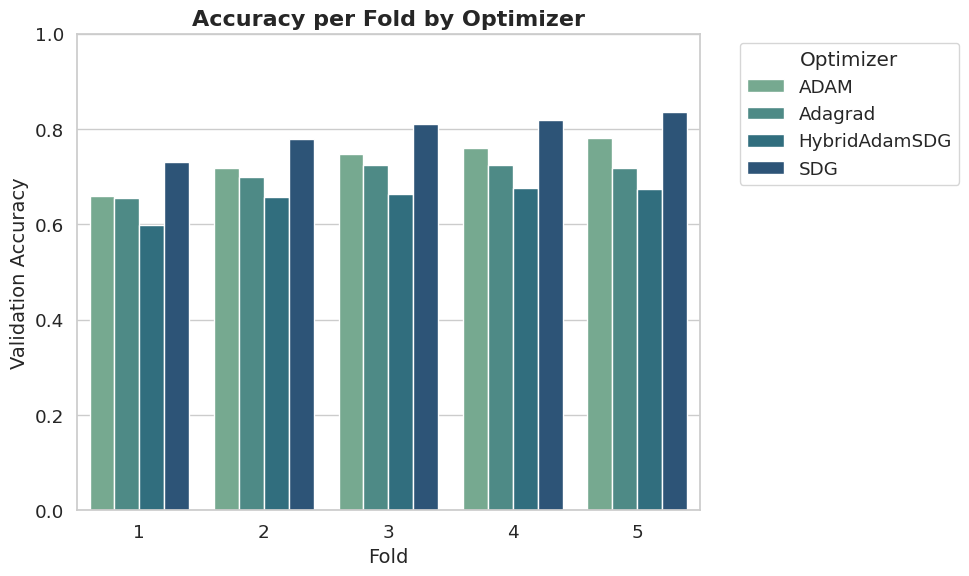

In [38]:
plt.figure(figsize=(10,6))
fold_acc = df.groupby(['Round_Fold','Optimizer'])['TrainAcc'].mean().reset_index()
sns.barplot(data=fold_acc, x='Round_Fold', y='TrainAcc', hue='Optimizer', palette='crest')

plt.title("Accuracy per Fold by Optimizer", fontsize=16, fontweight='bold')
plt.xlabel("Fold", fontsize=14)
plt.ylabel("Validation Accuracy", fontsize=14)
plt.ylim(0,1)
plt.legend(title='Optimizer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR/"Accuracy_Per_Fold_by_Optimizers.png", dpi=1200)
plt.show()


/tmp/ipykernel_10836/833765254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('Optimizer')['TimeSec'].mean().reset_index(),


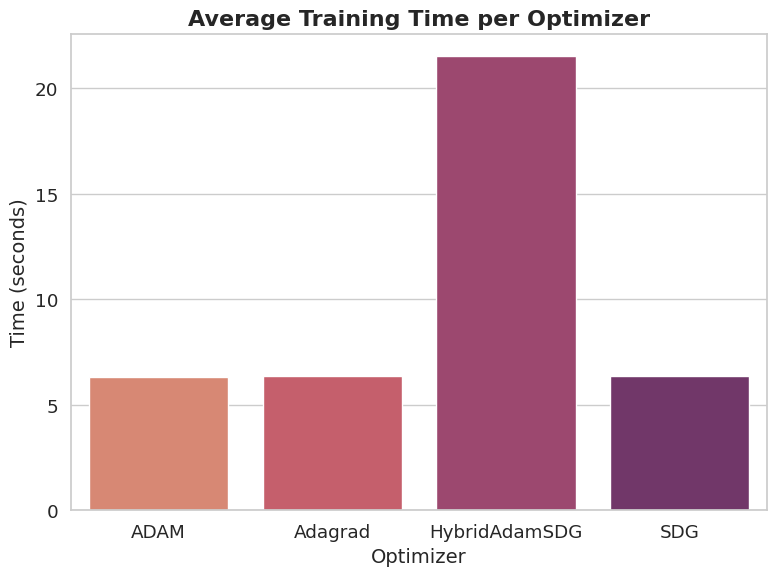

In [39]:
plt.figure(figsize=(8,6))
sns.barplot(data=df.groupby('Optimizer')['TimeSec'].mean().reset_index(),
            x='Optimizer', y='TimeSec', palette='flare')

plt.title("Average Training Time per Optimizer", fontsize=16, fontweight='bold')
plt.xlabel("Optimizer", fontsize=14)
plt.ylabel("Time (seconds)", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR/"Average_Training_Time_per_Optimizer.png", dpi=1200)
plt.show()


In [40]:
import pandas as pd

# Load your CSV
df = pd.read_csv("/mnt/c/Users/hassa/OneDrive/Desktop/QML/FINAL_RESEARCH_DATA.csv")

# Group by Optimizer and ModelType, compute summary stats
summary = (
    df.groupby(["Optimizer", "ModelType"])
      .agg(
          Max_Validation_Accuracy=("ValAcc", "max"),
          Min_Validation_Loss=("ValLoss", "min"),
          Max_Training_Accuracy=("TrainAcc", "max"),
          Min_Training_Loss=("TrainLoss", "min"),
          Average_Time_per_Epoch=("TimeSec", "mean")
      )
      .reset_index()
)

# Round values for readability
summary = summary.round(4)

print(summary)

# Optionally save to CSV for inclusion in paper
summary.to_csv("summary_table.csv", index=False)


        Optimizer              ModelType  Max_Validation_Accuracy  \
0            ADAM          FEDERATED CNN                   0.9962   
1            ADAM  FEDERATED QUANTUM CNN                   0.7627   
2            ADAM                  MLCNN                   0.9720   
3            ADAM            QUANTUM CNN                   0.7408   
4         Adagrad          FEDERATED CNN                   0.4987   
5         Adagrad  FEDERATED QUANTUM CNN                   0.4102   
6         Adagrad                  MLCNN                   0.8705   
7         Adagrad            QUANTUM CNN                   0.8224   
8   HybridAdamSDG          FEDERATED CNN                      NaN   
9   HybridAdamSDG  FEDERATED QUANTUM CNN                      NaN   
10  HybridAdamSDG                  MLCNN                   0.9685   
11  HybridAdamSDG            QUANTUM CNN                   0.7040   
12            SDG          FEDERATED CNN                   0.4978   
13            SDG  FEDERATED QUANT